# MAgent2 MF-DSRQ Torch Evaluation

Evaluate trained MF-DSRQ torch robust-epsilon checkpoints against PyTorch MFRL baselines on `battle_v4`. Each epsilon cell compares MF-DSRQ against IQL, AC, and MFQ with both red/blue side assignments.

In [1]:
from pathlib import Path
import json
import os
import sys

import pandas as pd
import torch


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "discrete_action_space").is_dir() and (path / "requirements.txt").exists():
            return path
    raise RuntimeError("Could not find the SRE-DQN repo root from the current notebook directory.")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from discrete_action_space.mean_field_dsrq.notebook_utils import (
    evaluate_mfdsrq_torch_epsilon_fixed_side_tournament,
    find_latest_mfrl_run,
    load_mfdsrq_config,
    mfdsrq_epsilon_config,
    plot_fixed_side_tournament_bars,
)

MAP_SIZE = 40
MAX_CYCLES = 400
SEED = 42
ROBUST_DISTANCE = "tv"
ROBUST_POLICY_TEMPERATURE = 0.1
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EVAL_EPISODES_PER_MATCHUP = 500
TOURNAMENT_ALGORITHMS = ("mfdsrq", "iql", "ac", "mfq")
BASELINE_ALGORITHMS = tuple(algorithm for algorithm in TOURNAMENT_ALGORITHMS if algorithm != "mfdsrq")
FULL_MATCHUP_PAIRS = tuple(
    (main_algorithm, opponent_algorithm)
    for main_algorithm in TOURNAMENT_ALGORITHMS
    for opponent_algorithm in TOURNAMENT_ALGORITHMS
)
BASELINE_ONLY_MATCHUP_PAIRS = tuple(
    (main_algorithm, opponent_algorithm)
    for main_algorithm in BASELINE_ALGORITHMS
    for opponent_algorithm in BASELINE_ALGORITHMS
)
MFDSRQ_MATCHUP_PAIRS = tuple(
    pair for pair in FULL_MATCHUP_PAIRS
    if "mfdsrq" in pair
)
EVAL_WORKERS = 8 # cap concurrent Battle envs to avoid WSL CPU/memory spikes
EVAL_EPISODE_CHUNK_SIZE = EVAL_EPISODES_PER_MATCHUP
EVAL_SHOW_PROGRESS = True
EVAL_MAX_STEPS = MAX_CYCLES
TRAINING_PLOT_SMOOTHING_WINDOW = 50

RUNS_ROOT = ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
MFDSRQ_OUTPUT_ROOT = RUNS_ROOT / "mf_srq_torch_epsilon_training_v4_opp"
MFDSRQ_DECAY_OUTPUT_ROOT = RUNS_ROOT / "mf_srq_torch_epsilon_decay_to_zero_v4_opp"
MFDSRQ_RAMP_OUTPUT_ROOT = RUNS_ROOT / "mf_srq_torch_epsilon_ramp_up"
BASELINE_ROOT = RUNS_ROOT / "mfrl_baselines"
BASELINE_EVAL_DIR = BASELINE_ROOT / "evaluation"
BASELINE_ONLY_TOURNAMENT_PATH = BASELINE_EVAL_DIR / "baseline_only_tournament.json"

BASE_CFG = load_mfdsrq_config(
    overrides={
        "algorithm": "mf_srq_torch",
        "env_name": "battle_v4",
        "env_backend": "magent2",
        "map_size": MAP_SIZE,
        "max_cycles": MAX_CYCLES,
        "output_dir": str(MFDSRQ_OUTPUT_ROOT),
        "seed": SEED,
        "device": DEVICE,
        "use_gpu": DEVICE == "cuda",
        "robust_policy_temperature": ROBUST_POLICY_TEMPERATURE,
    },
)


def epsilon_slug(epsilon):
    text = f"{float(epsilon):g}".replace(".", "_").replace("-", "neg_")
    return f"eps_{text}"


def schedule_slug(epsilon_start, epsilon_end):
    return f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")


def seed_run_dir(output_dir):
    return Path(output_dir) / "battle_v4" / f"seed{SEED}"


def checkpoint_paths_for_run(run_dir):
    run_dir = Path(run_dir)
    return {
        "main": run_dir / "ckpt_main_best.pt",
        "opponent": run_dir / "ckpt_opponent_best.pt",
    }


def fixed_epsilon_spec(epsilon):
    cfg = mfdsrq_epsilon_config(BASE_CFG, epsilon, MFDSRQ_OUTPUT_ROOT)
    run_dir = seed_run_dir(Path(cfg["output_dir"]))
    return {
        "group": "fixed",
        "epsilon": float(epsilon),
        "epsilon_for_eval": float(epsilon),
        "label": f"fixed eps={epsilon:g}",
        "cfg": cfg,
        "run_dir": run_dir,
        "checkpoint_paths": checkpoint_paths_for_run(run_dir),
    }


def scheduled_epsilon_spec(group, epsilon_start, epsilon_end, output_root):
    slug = schedule_slug(epsilon_start, epsilon_end)
    cfg = dict(BASE_CFG)
    cfg.update({
        "epsilon_robust_start": float(epsilon_start),
        "epsilon_robust_end": float(epsilon_end),
        "epsilon_robust_decay_frac": 1.0,
        "output_dir": str(Path(output_root) / slug),
    })
    run_dir = seed_run_dir(Path(cfg["output_dir"]))
    arrow = "decay" if group == "decay_to_zero" else "ramp"
    return {
        "group": group,
        "epsilon": float(epsilon_end),
        "epsilon_for_eval": float(epsilon_end),
        "label": f"{arrow} eps {epsilon_start:g}->{epsilon_end:g}",
        "cfg": cfg,
        "run_dir": run_dir,
        "checkpoint_paths": checkpoint_paths_for_run(run_dir),
    }


MFDSRQ_MODEL_SPECS = {
    "fixed_0_01": fixed_epsilon_spec(0.01),
    "fixed_0_1": fixed_epsilon_spec(0.1),
    "fixed_0_5": fixed_epsilon_spec(0.5),
    "fixed_1_0": fixed_epsilon_spec(1.0),
    "decay_0_5_to_0": scheduled_epsilon_spec("decay_to_zero", 0.5, 0.0, MFDSRQ_DECAY_OUTPUT_ROOT),
    "decay_0_75_to_0": scheduled_epsilon_spec("decay_to_zero", 0.75, 0.0, MFDSRQ_DECAY_OUTPUT_ROOT),
    "decay_1_0_to_0": scheduled_epsilon_spec("decay_to_zero", 1.0, 0.0, MFDSRQ_DECAY_OUTPUT_ROOT),
    "ramp_0_01_to_0_5": scheduled_epsilon_spec("ramp_up", 0.01, 0.5, MFDSRQ_RAMP_OUTPUT_ROOT),
    "ramp_0_01_to_1_0": scheduled_epsilon_spec("ramp_up", 0.01, 1.0, MFDSRQ_RAMP_OUTPUT_ROOT),
    "ramp_0_1_to_0_5": scheduled_epsilon_spec("ramp_up", 0.1, 0.5, MFDSRQ_RAMP_OUTPUT_ROOT),
    "ramp_0_1_to_1_0": scheduled_epsilon_spec("ramp_up", 0.1, 1.0, MFDSRQ_RAMP_OUTPUT_ROOT),
}

FIXED_MODEL_KEYS = ("fixed_0_01", "fixed_0_1", "fixed_0_5", "fixed_1_0")
DECAY_TO_ZERO_MODEL_KEYS = ("decay_0_5_to_0", "decay_0_75_to_0", "decay_1_0_to_0")
RAMP_UP_MODEL_KEYS = ("ramp_0_01_to_0_5", "ramp_0_01_to_1_0", "ramp_0_1_to_0_5", "ramp_0_1_to_1_0")
ALL_MODEL_KEYS = FIXED_MODEL_KEYS + DECAY_TO_ZERO_MODEL_KEYS + RAMP_UP_MODEL_KEYS

BASELINE_RUN_DIRS = {
    algorithm: find_latest_mfrl_run(algorithm, BASELINE_ROOT)
    for algorithm in BASELINE_ALGORITHMS
}
TOURNAMENTS = {}


def fixed_side_tournament_table(tournament):
    return pd.DataFrame([
        {
            "main algo name": row["main_algorithm"],
            "opponent algo name": row["opponent_algorithm"],
            "main win rate": row["main_win_rate"],
            "opponent win rate": row["opponent_win_rate"],
            "avg main kills": row["mean_main_kills"],
            "avg opponent kills": row["mean_opponent_kills"],
            "avg main rewards": row["mean_main_reward"],
            "avg opponent rewards": row["mean_opponent_reward"],
        }
        for row in tournament["rows"]
    ])


def _pair_key(row):
    return (str(row["main_algorithm"]).lower(), str(row["opponent_algorithm"]).lower())


def merge_fixed_side_tournaments(mfdsrq_tournament, baseline_tournament):
    rows_by_pair = {_pair_key(row): dict(row) for row in baseline_tournament["rows"]}
    rows_by_pair.update({_pair_key(row): dict(row) for row in mfdsrq_tournament["rows"]})
    missing_pairs = [pair for pair in FULL_MATCHUP_PAIRS if pair not in rows_by_pair]
    if missing_pairs:
        raise ValueError(f"Merged tournament is missing matchup rows: {missing_pairs}")

    merged = dict(mfdsrq_tournament)
    merged["algorithms"] = list(TOURNAMENT_ALGORITHMS)
    merged["matchup_pairs"] = [list(pair) for pair in FULL_MATCHUP_PAIRS]
    merged["num_episodes_per_matchup"] = int(EVAL_EPISODES_PER_MATCHUP)
    merged["rows"] = [rows_by_pair[pair] for pair in FULL_MATCHUP_PAIRS]
    merged["matchups"] = {
        main_algorithm: {
            opponent_algorithm: (
                mfdsrq_tournament.get("matchups", {}).get(main_algorithm, {}).get(opponent_algorithm)
                or baseline_tournament.get("matchups", {}).get(main_algorithm, {}).get(opponent_algorithm)
            )
            for opponent_algorithm in TOURNAMENT_ALGORITHMS
        }
        for main_algorithm in TOURNAMENT_ALGORITHMS
    }
    return merged


def save_fixed_side_tournament(tournament):
    out_path = Path(tournament["checkpoint_dir"]) / "fixed_side_tournament.json"
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(tournament, f, indent=2)
    tournament["results_path"] = str(out_path)
    print(f"Saved fixed-side tournament to {out_path}")
    return out_path


def load_baseline_only_tournament():
    with open(BASELINE_ONLY_TOURNAMENT_PATH, encoding="utf-8") as f:
        tournament = json.load(f)
    tournament["results_path"] = str(BASELINE_ONLY_TOURNAMENT_PATH)
    print(f"Loaded cached baseline-only tournament from {BASELINE_ONLY_TOURNAMENT_PATH}")
    return tournament


def save_baseline_only_tournament(tournament):
    BASELINE_EVAL_DIR.mkdir(parents=True, exist_ok=True)
    tournament = dict(tournament)
    tournament["results_path"] = str(BASELINE_ONLY_TOURNAMENT_PATH)
    with open(BASELINE_ONLY_TOURNAMENT_PATH, "w", encoding="utf-8") as f:
        json.dump(tournament, f, indent=2)
    print(f"Saved baseline-only tournament to {BASELINE_ONLY_TOURNAMENT_PATH}")
    return tournament


def evaluate_and_plot_model(model_key):
    if "BASELINE_ONLY_TOURNAMENT" not in globals():
        raise RuntimeError("Run the baseline-only tournament cell before evaluating MF-DSRQ models.")
    spec = MFDSRQ_MODEL_SPECS[model_key]
    mfdsrq_tournament = evaluate_mfdsrq_torch_epsilon_fixed_side_tournament(
        spec["cfg"],
        spec["epsilon_for_eval"],
        spec["checkpoint_paths"],
        baseline_root=BASELINE_ROOT,
        algorithms=TOURNAMENT_ALGORITHMS,
        matchup_pairs=MFDSRQ_MATCHUP_PAIRS,
        baseline_folders=BASELINE_RUN_DIRS,
        num_episodes_per_matchup=EVAL_EPISODES_PER_MATCHUP,
        max_steps=EVAL_MAX_STEPS,
        workers=EVAL_WORKERS,
        episode_chunk_size=EVAL_EPISODE_CHUNK_SIZE,
        show_progress=EVAL_SHOW_PROGRESS,
        save=False,
        device=DEVICE,
        experiment_label=spec["label"],
    )
    tournament = merge_fixed_side_tournaments(mfdsrq_tournament, BASELINE_ONLY_TOURNAMENT)
    tournament["model_key"] = model_key
    tournament["model_label"] = spec["label"]
    save_fixed_side_tournament(tournament)
    _ = plot_fixed_side_tournament_bars(tournament, save=True)
    summary_table = fixed_side_tournament_table(tournament)
    if not summary_table.empty:
        print(summary_table.to_string(index=False))
    return tournament


def load_training_stats(model_key):
    stats_path = MFDSRQ_MODEL_SPECS[model_key]["run_dir"] / "training_stats.json"
    if not stats_path.exists():
        print(f"Skipping {model_key}: no training_stats.json at {stats_path}")
        return None
    with open(stats_path, encoding="utf-8") as f:
        return json.load(f)


def load_baseline_training_stats(algorithm):
    stats_path = Path(BASELINE_RUN_DIRS[algorithm]) / "training_stats.json"
    if not stats_path.exists():
        print(f"Skipping {algorithm}: no training_stats.json at {stats_path}")
        return None
    with open(stats_path, encoding="utf-8") as f:
        return json.load(f)


def wins_from_record(record, team):
    if "wins" in record:
        return int(record["wins"].get(team, 0))
    if "winner" in record:
        return int(record.get("winner") == team)
    kills = record.get("kills", {})
    teams = list(record.get("rewards", {}).keys()) or ["main", "opponent"]
    team_kills = {name: int(kills.get(name, 0)) for name in teams}
    if not team_kills:
        return 0
    max_kills = max(team_kills.values())
    return int(team_kills.get(team, 0) == max_kills and list(team_kills.values()).count(max_kills) == 1)


def history_frame_from_stats(stats):
    if stats is None:
        return pd.DataFrame()
    records = stats.get("episode_records") or stats.get("records", [])
    rows = []
    for record in records:
        rows.append({
            "episode": record.get("episode", len(rows) + 1),
            "env_idx": record.get("env_idx", 0),
            "reward_main": record.get("rewards", {}).get("main", 0.0),
            "reward_opponent": record.get("rewards", {}).get("opponent", 0.0),
            "win_main": wins_from_record(record, "main"),
            "win_opponent": wins_from_record(record, "opponent"),
            "kills_main": record.get("kills", {}).get("main", 0),
            "kills_opponent": record.get("kills", {}).get("opponent", 0),
        })
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows).sort_values(["episode", "env_idx"]).reset_index(drop=True)
    df["episode_index"] = range(1, len(df) + 1)
    df["cum_win_main"] = df["win_main"].cumsum()
    df["cum_win_opponent"] = df["win_opponent"].cumsum()
    return df


def training_history_frame(model_key):
    return history_frame_from_stats(load_training_stats(model_key))


def baseline_training_history_frame(algorithm):
    return history_frame_from_stats(load_baseline_training_stats(algorithm))


def training_history_series(model_keys):
    series = []
    for model_key in model_keys:
        spec = MFDSRQ_MODEL_SPECS[model_key]
        series.append((spec["label"], training_history_frame(model_key)))
    for algorithm in BASELINE_ALGORITHMS:
        series.append((algorithm.upper(), baseline_training_history_frame(algorithm)))
    return series


def plot_training_history_group(model_keys, title, save_name, smoothing_window=TRAINING_PLOT_SMOOTHING_WINDOW, save=True):
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(3, 2, figsize=(16, 11))
    axes = axes.reshape(3, 2)
    for label, df in training_history_series(model_keys):
        if df.empty:
            continue
        axes[0, 0].plot(
            df["episode_index"],
            df["reward_main"].rolling(smoothing_window, min_periods=1).mean(),
            label=label,
        )
        axes[0, 1].plot(
            df["episode_index"],
            df["reward_opponent"].rolling(smoothing_window, min_periods=1).mean(),
            label=label,
        )
        axes[1, 0].plot(df["episode_index"], df["cum_win_main"], label=label)
        axes[1, 1].plot(df["episode_index"], df["cum_win_opponent"], label=label)
        axes[2, 0].plot(
            df["episode_index"],
            df["kills_main"].rolling(smoothing_window, min_periods=1).mean(),
            label=label,
        )
        axes[2, 1].plot(
            df["episode_index"],
            df["kills_opponent"].rolling(smoothing_window, min_periods=1).mean(),
            label=label,
        )

    axes[0, 0].set_title(f"Main training rewards, rolling mean {smoothing_window}")
    axes[0, 1].set_title(f"Opponent training rewards, rolling mean {smoothing_window}")
    axes[1, 0].set_title("Main cumulative wins")
    axes[1, 1].set_title("Opponent cumulative wins")
    axes[2, 0].set_title(f"Main kills, rolling mean {smoothing_window}")
    axes[2, 1].set_title(f"Opponent kills, rolling mean {smoothing_window}")
    for ax in axes.ravel():
        ax.set_xlabel("Completed episode")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    if save:
        out_path = MFDSRQ_OUTPUT_ROOT / f"{save_name}.png"
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Saved training history plot to {out_path}")
    return fig

{
    "baseline_root": str(BASELINE_ROOT),
    "baseline_eval_dir": str(BASELINE_EVAL_DIR),
    "baseline_only_tournament_path": str(BASELINE_ONLY_TOURNAMENT_PATH),
    "device": DEVICE,
    "cuda_available": torch.cuda.is_available(),
    "tournament_algorithms": TOURNAMENT_ALGORITHMS,
    "full_matchup_pairs": FULL_MATCHUP_PAIRS,
    "baseline_only_matchup_pairs": BASELINE_ONLY_MATCHUP_PAIRS,
    "mfdsrq_matchup_pairs": MFDSRQ_MATCHUP_PAIRS,
    "eval_episodes_per_matchup": EVAL_EPISODES_PER_MATCHUP,
    "eval_workers": EVAL_WORKERS,
    "eval_episode_chunk_size": EVAL_EPISODE_CHUNK_SIZE,
    "training_plot_smoothing_window": TRAINING_PLOT_SMOOTHING_WINDOW,
    "model_specs": {
        key: {
            "label": spec["label"],
            "run_dir": str(spec["run_dir"]),
            "checkpoint_paths": {team: str(path) for team, path in spec["checkpoint_paths"].items()},
        }
        for key, spec in MFDSRQ_MODEL_SPECS.items()
    },
}


{'baseline_root': '/home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mfrl_baselines',
 'baseline_eval_dir': '/home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mfrl_baselines/evaluation',
 'baseline_only_tournament_path': '/home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mfrl_baselines/evaluation/baseline_only_tournament.json',
 'device': 'cuda',
 'cuda_available': True,
 'tournament_algorithms': ('mfdsrq', 'iql', 'ac', 'mfq'),
 'full_matchup_pairs': (('mfdsrq', 'mfdsrq'),
  ('mfdsrq', 'iql'),
  ('mfdsrq', 'ac'),
  ('mfdsrq', 'mfq'),
  ('iql', 'mfdsrq'),
  ('iql', 'iql'),
  ('iql', 'ac'),
  ('iql', 'mfq'),
  ('ac', 'mfdsrq'),
  ('ac', 'iql'),
  ('ac', 'ac'),
  ('ac', 'mfq'),
  ('mfq', 'mfdsrq'),
  ('mfq', 'iql'),
  ('mfq', 'ac'),
  ('mfq', 'mfq')),
 'baseline_only_matchup_pairs': (('iql', 'iql'),
  ('iql', 'ac'),
  ('iql', 'mfq'),
  ('ac', 'iql'),
  ('ac', 'ac'),
  ('ac', 'mfq'),
  ('mfq', 'iql'),
  ('mfq', 'ac'),
  ('mfq', 'mfq'

## Baseline Checkpoints

In [2]:
pd.DataFrame([
    {"algorithm": algorithm, "run_dir": str(run_dir)}
    for algorithm, run_dir in BASELINE_RUN_DIRS.items()
])


,algorithm,run_dir
0,iql,/home/wowthecoder/SRE-DQN/discrete_action_spac...
1,ac,/home/wowthecoder/SRE-DQN/discrete_action_spac...
2,mfq,/home/wowthecoder/SRE-DQN/discrete_action_spac...


## Fixed Robust Epsilon Tournaments


## Reusable Baseline-Only Tournament


In [3]:
if BASELINE_ONLY_TOURNAMENT_PATH.exists():
    BASELINE_ONLY_TOURNAMENT = load_baseline_only_tournament()
else:
    if BASELINE_EVAL_DIR.exists():
        print(f"Baseline evaluation folder exists but cache file is missing: {BASELINE_ONLY_TOURNAMENT_PATH}")
    baseline_spec = MFDSRQ_MODEL_SPECS["fixed_0_01"]
    BASELINE_ONLY_TOURNAMENT = evaluate_mfdsrq_torch_epsilon_fixed_side_tournament(
        baseline_spec["cfg"],
        baseline_spec["epsilon_for_eval"],
        baseline_spec["checkpoint_paths"],
        baseline_root=BASELINE_ROOT,
        algorithms=TOURNAMENT_ALGORITHMS,
        matchup_pairs=BASELINE_ONLY_MATCHUP_PAIRS,
        baseline_folders=BASELINE_RUN_DIRS,
        num_episodes_per_matchup=EVAL_EPISODES_PER_MATCHUP,
        max_steps=EVAL_MAX_STEPS,
        workers=EVAL_WORKERS,
        episode_chunk_size=EVAL_EPISODE_CHUNK_SIZE,
        show_progress=EVAL_SHOW_PROGRESS,
        save=False,
        device=DEVICE,
        experiment_label="baseline-only",
    )
    BASELINE_ONLY_TOURNAMENT = save_baseline_only_tournament(BASELINE_ONLY_TOURNAMENT)
fixed_side_tournament_table(BASELINE_ONLY_TOURNAMENT)


Loaded cached baseline-only tournament from /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mfrl_baselines/evaluation/baseline_only_tournament.json


,main algo name,opponent algo name,main win rate,opponent win rate,avg main kills,avg opponent kills,avg main rewards,avg opponent rewards
0,iql,iql,0.500,0.500,50.270,47.804,233.453977,217.030379
1,iql,ac,0.000,1.000,23.828,63.928,83.704734,289.629540
2,iql,mfq,0.000,1.000,25.798,64.000,92.361025,315.205226
3,ac,iql,1.000,0.000,63.914,22.738,293.901538,78.437894
4,ac,ac,0.498,0.502,53.886,53.484,275.388299,271.861219
5,ac,mfq,0.986,0.012,63.916,43.302,316.766617,203.523710
6,mfq,iql,1.000,0.000,63.934,29.844,304.106907,108.670302
7,mfq,ac,0.056,0.944,47.510,63.558,222.979880,313.478098
8,mfq,mfq,0.502,0.498,53.688,55.530,256.106814,270.365585


## Fixed Robust Epsilon 0.01


MF-DSRQ eps=0.01 eval episodes:   0%|                                                          | 0/3500 [00:00…

Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_01/battle_v4/seed42/ckpt_main_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_01/battle_v4/seed42/ckpt_opponent_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_01/battle_v4/seed42/ckpt_main_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_01/battle_v4/seed42/ckpt_opponent_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_01/battle_v4/seed42/ckpt_opponent_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_01/battle_v4/seed42/ckpt_main_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_acti

,main algo name,opponent algo name,main win rate,opponent win rate,avg main kills,avg opponent kills,avg main rewards,avg opponent rewards
0,mfdsrq,mfdsrq,0.586,0.408,60.502,53.700,255.674067,228.079328
1,mfdsrq,iql,1.000,0.000,63.446,23.530,-166.238673,47.087670
2,mfdsrq,ac,0.524,0.430,61.330,59.272,263.805946,286.974934
3,mfdsrq,mfq,1.000,0.000,64.000,37.164,308.664816,173.329590
4,iql,mfdsrq,0.000,1.000,21.662,63.048,35.281842,-339.775298
5,iql,iql,0.500,0.500,50.270,47.804,233.453977,217.030379
6,iql,ac,0.000,1.000,23.828,63.928,83.704734,289.629540
7,iql,mfq,0.000,1.000,25.798,64.000,92.361025,315.205226
8,ac,mfdsrq,0.362,0.584,59.098,61.868,287.748555,267.575786
9,ac,iql,1.000,0.000,63.914,22.738,293.901538,78.437894


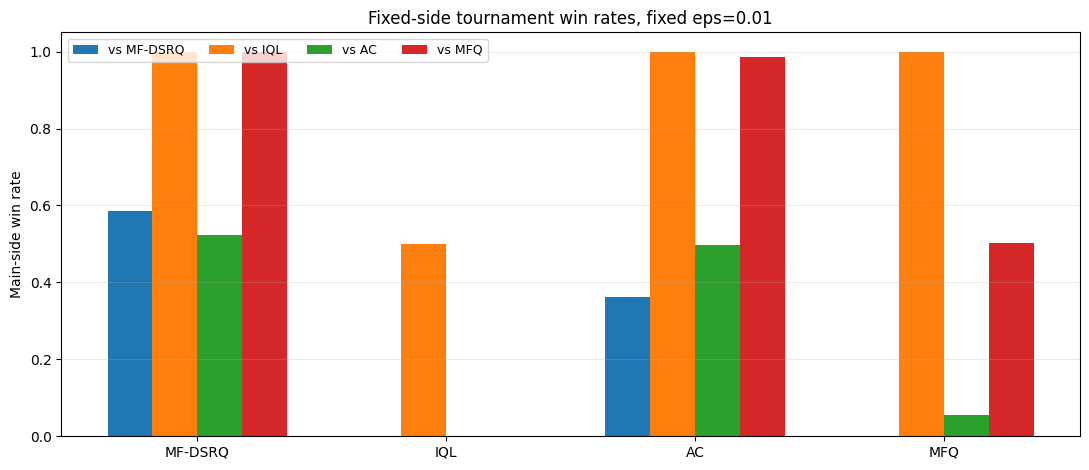

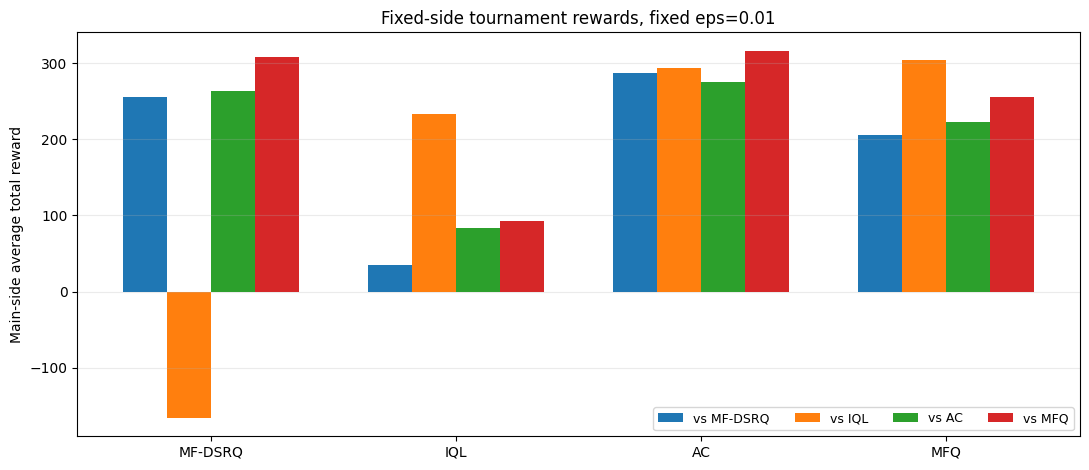

In [4]:
tournament_fixed_0_01 = evaluate_and_plot_model("fixed_0_01")
TOURNAMENTS["fixed_0_01"] = tournament_fixed_0_01
fixed_side_tournament_table(tournament_fixed_0_01)


## Fixed Robust Epsilon 0.01 Training History


Saved training history plot to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/fixed_0_01_training_history.png


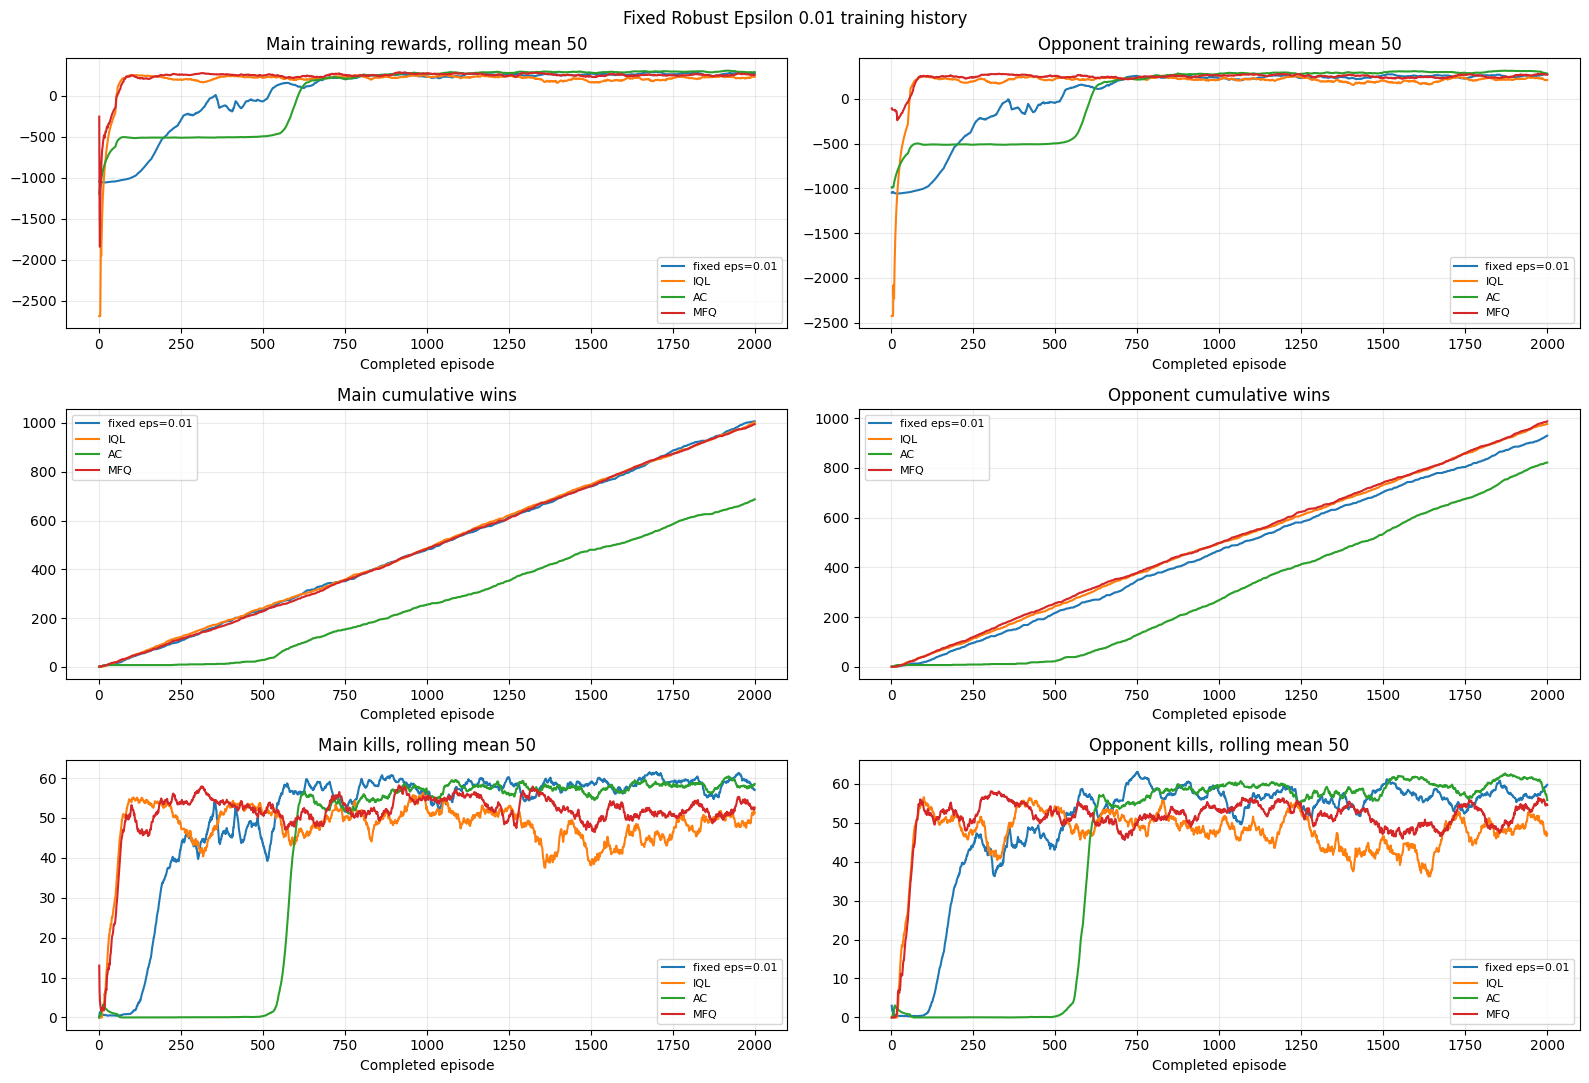

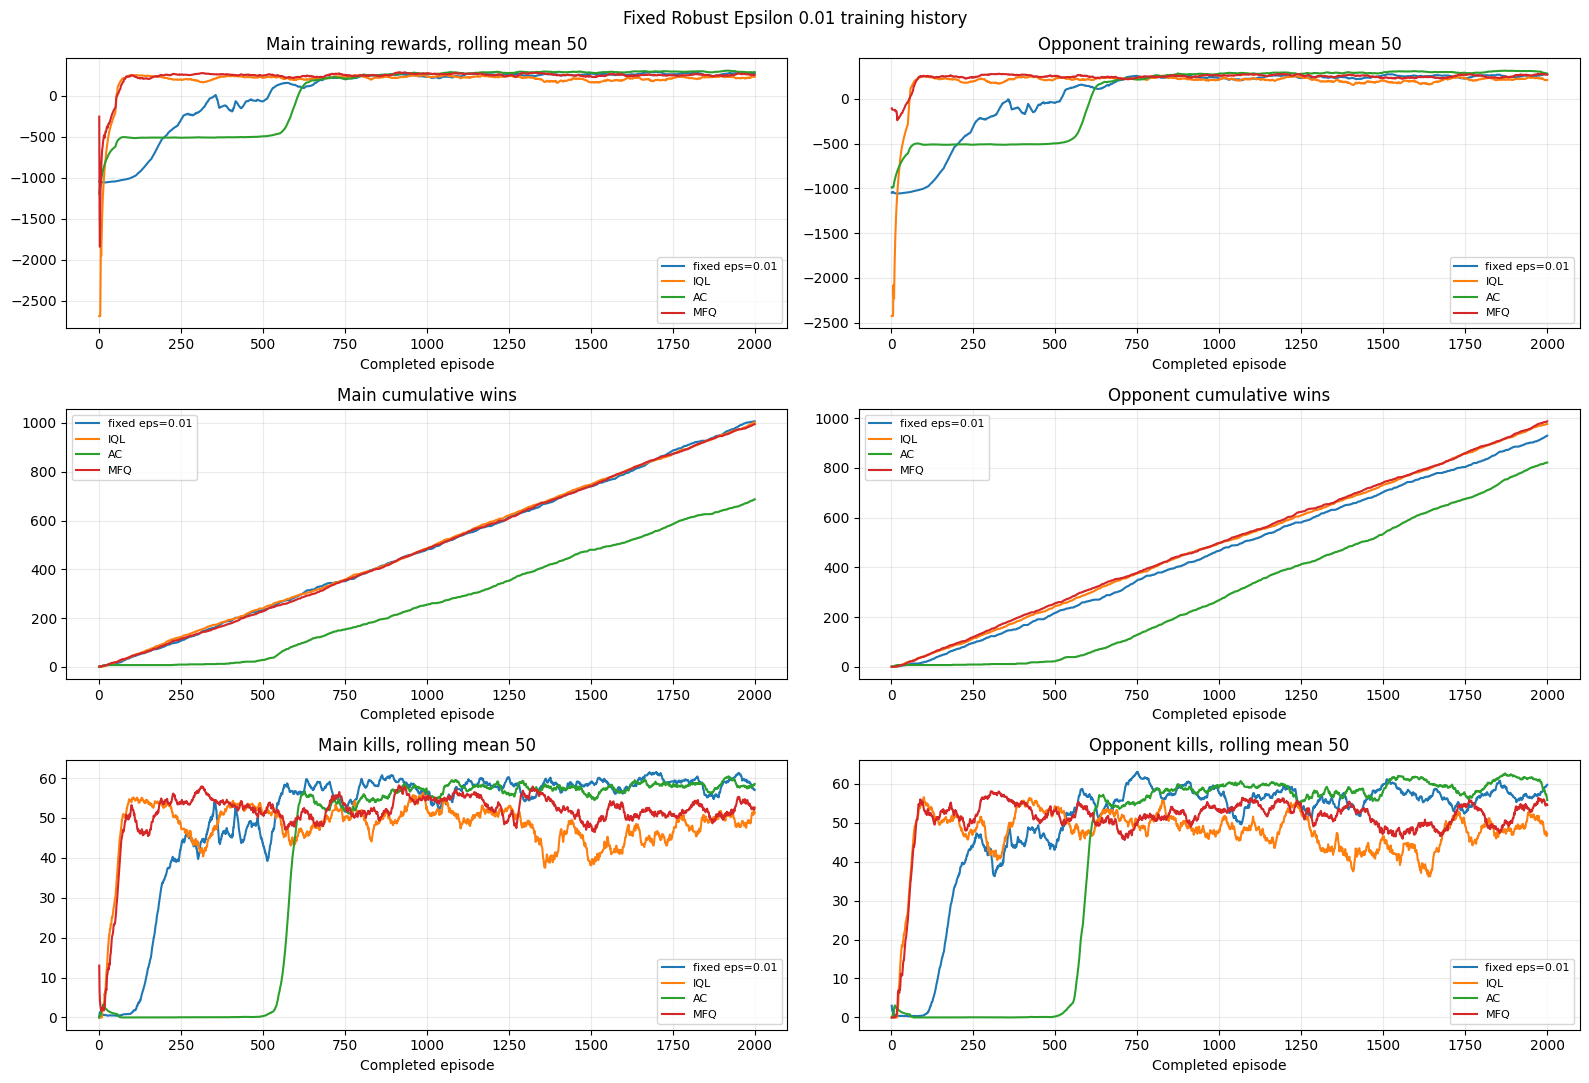

In [5]:
plot_training_history_group(
    ("fixed_0_01",),
    "Fixed Robust Epsilon 0.01 training history",
    "fixed_0_01_training_history",
)


## Fixed Robust Epsilon 0.1


MF-DSRQ eps=0.1 eval episodes:   0%|                                                           | 0/3500 [00:00…

Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_1/battle_v4/seed42/ckpt_opponent_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_1/battle_v4/seed42/ckpt_opponent_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_1/battle_v4/seed42/ckpt_main_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_1/battle_v4/seed42/ckpt_main_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_1/battle_v4/seed42/ckpt_opponent_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_1/battle_v4/seed42/ckpt_main_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_spa

,main algo name,opponent algo name,main win rate,opponent win rate,avg main kills,avg opponent kills,avg main rewards,avg opponent rewards
0,mfdsrq,mfdsrq,0.530,0.454,61.708,61.080,295.830557,291.410477
1,mfdsrq,iql,1.000,0.000,63.994,16.550,287.257762,50.529366
2,mfdsrq,ac,0.416,0.564,60.288,60.106,290.642183,290.820906
3,mfdsrq,mfq,1.000,0.000,64.000,35.834,311.164596,169.835762
4,iql,mfdsrq,0.000,1.000,20.062,63.998,71.083715,298.008575
5,iql,iql,0.500,0.500,50.270,47.804,233.453977,217.030379
6,iql,ac,0.000,1.000,23.828,63.928,83.704734,289.629540
7,iql,mfq,0.000,1.000,25.798,64.000,92.361025,315.205226
8,ac,mfdsrq,0.424,0.546,57.668,61.630,282.409789,298.703565
9,ac,iql,1.000,0.000,63.914,22.738,293.901538,78.437894


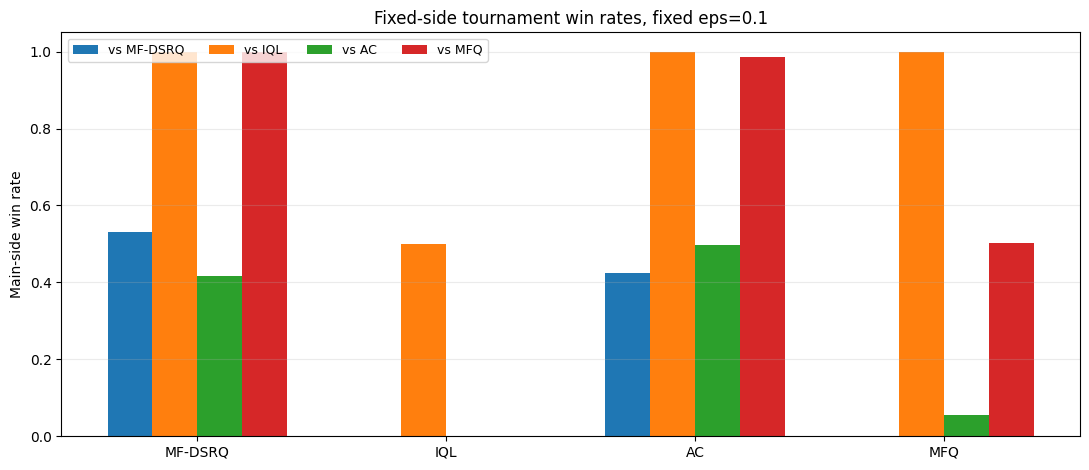

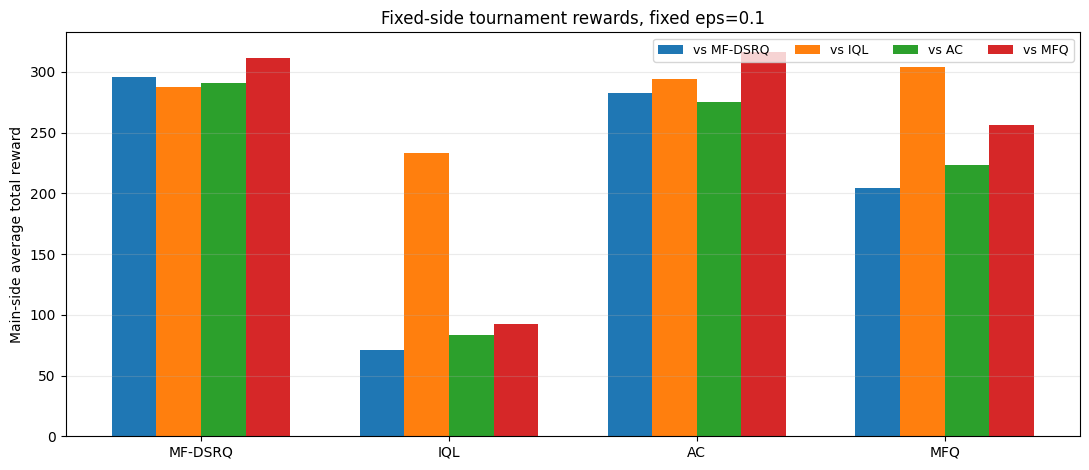

In [6]:
tournament_fixed_0_1 = evaluate_and_plot_model("fixed_0_1")
TOURNAMENTS["fixed_0_1"] = tournament_fixed_0_1
fixed_side_tournament_table(tournament_fixed_0_1)


## Fixed Robust Epsilon 0.1 Training History


Saved training history plot to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/fixed_0_1_training_history.png


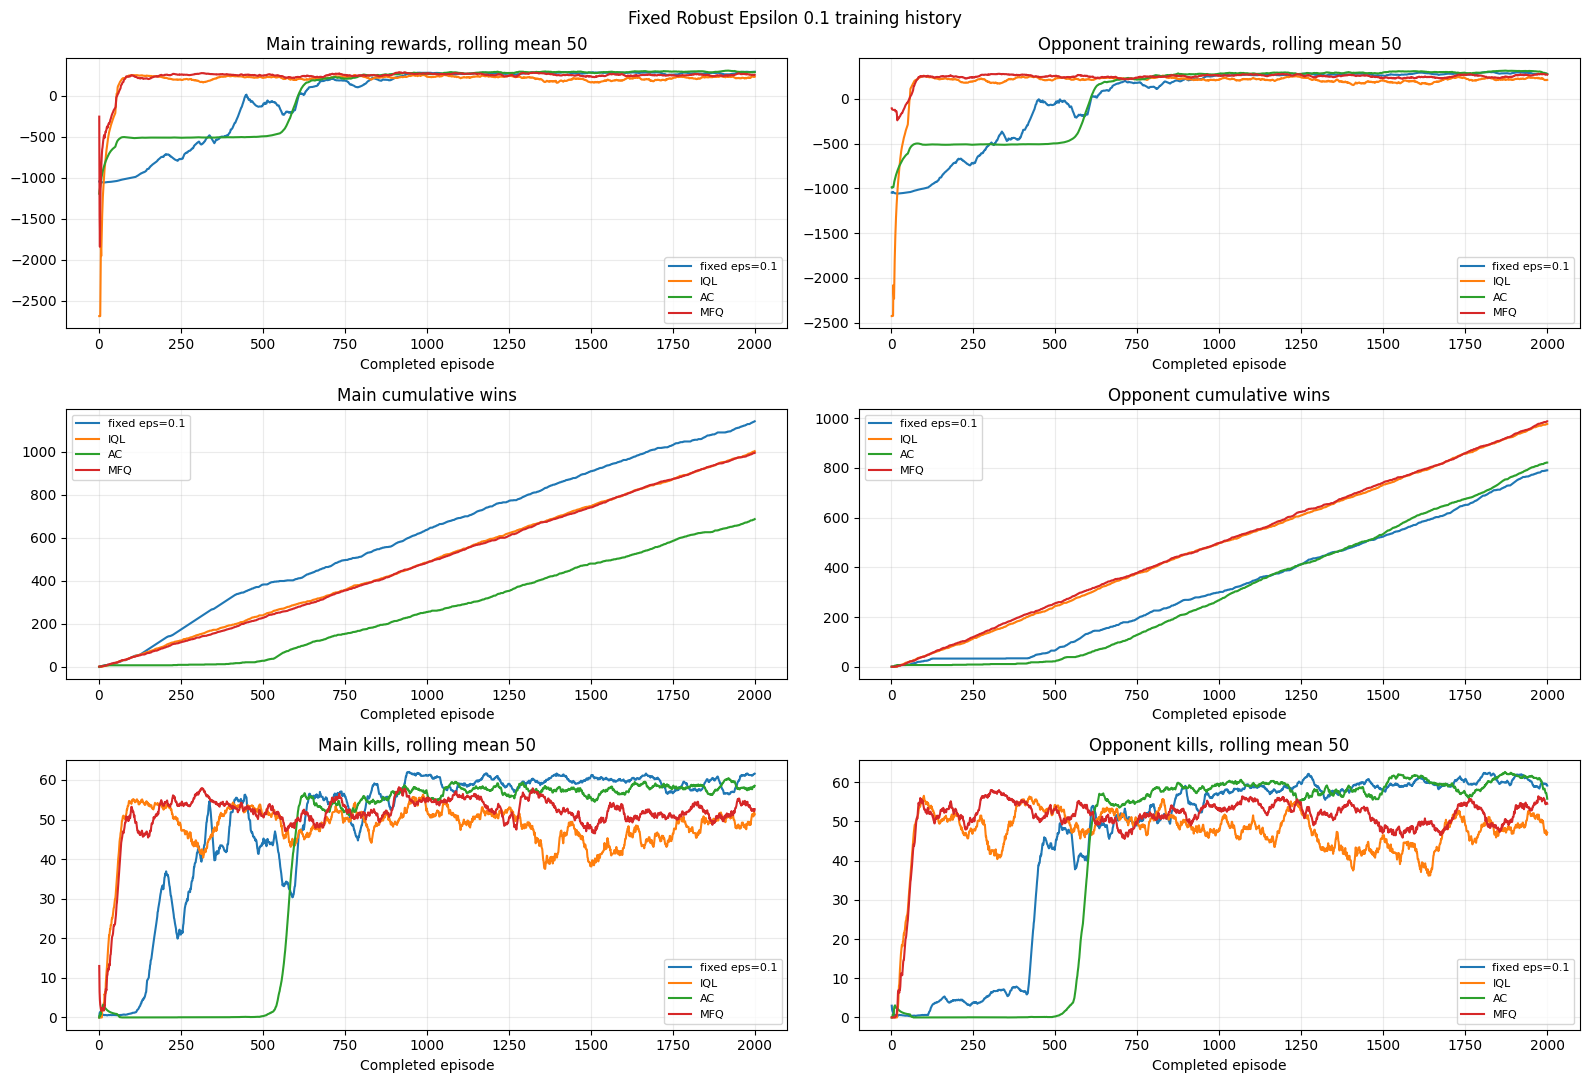

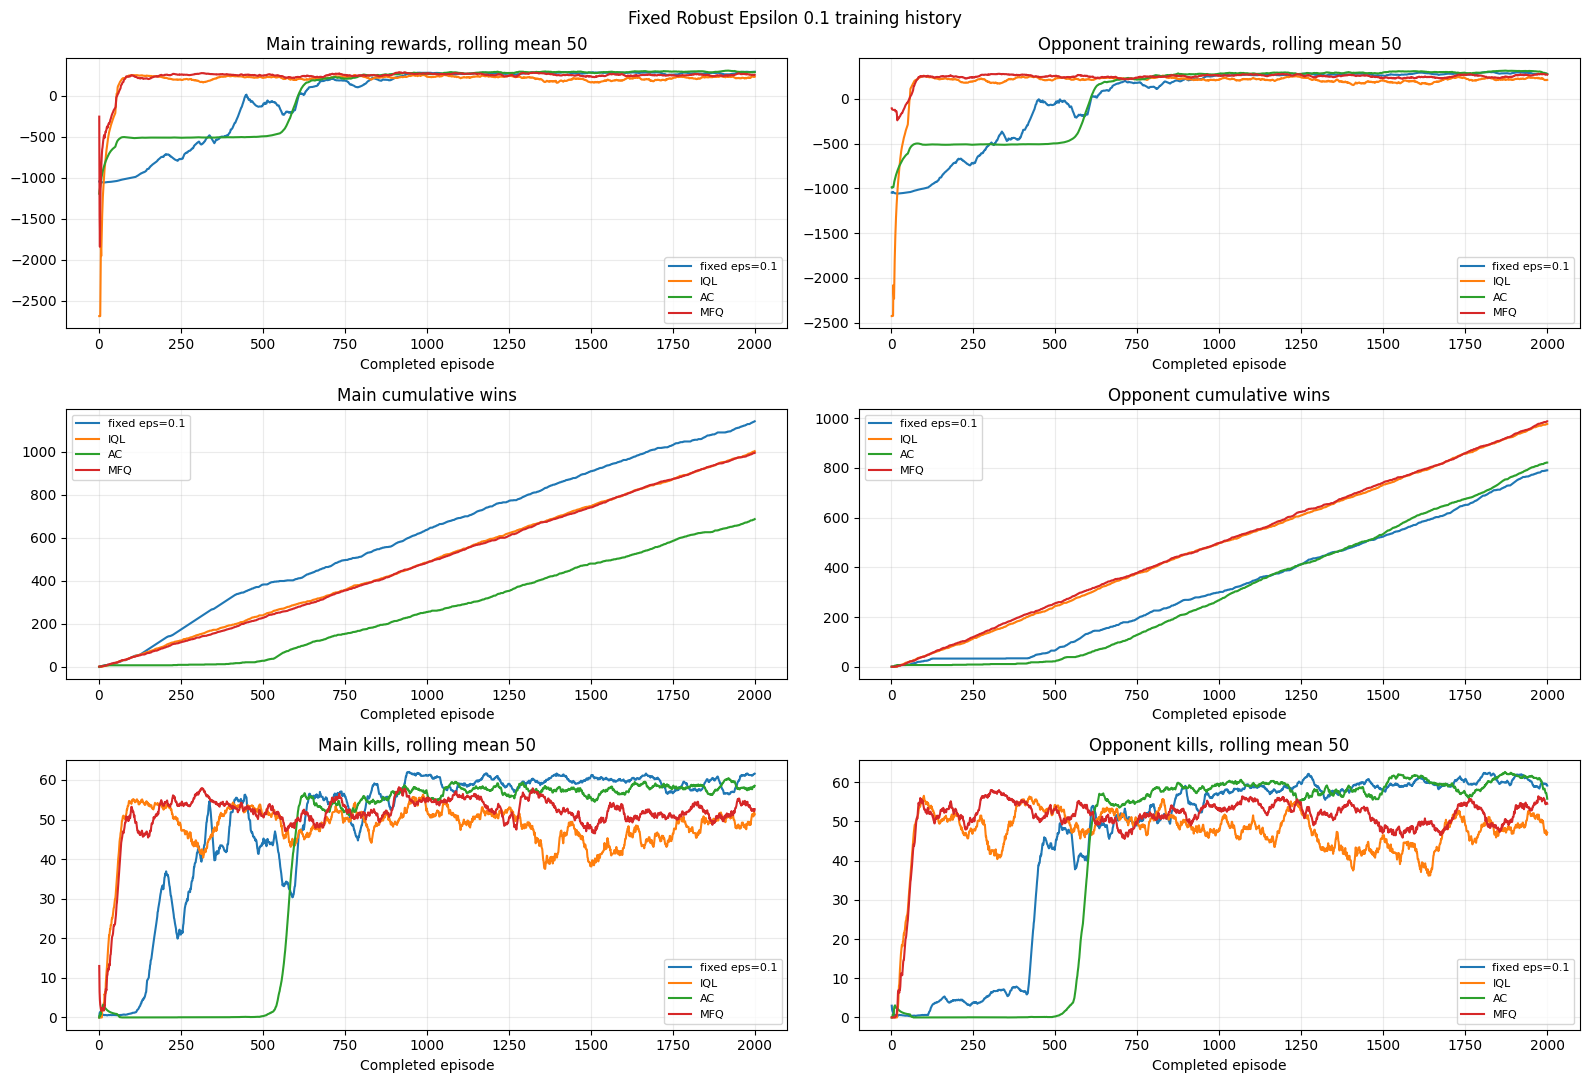

In [7]:
plot_training_history_group(
    ("fixed_0_1",),
    "Fixed Robust Epsilon 0.1 training history",
    "fixed_0_1_training_history",
)


## Fixed Robust Epsilon 0.5


MF-DSRQ eps=0.5 eval episodes:   0%|                                                           | 0/3500 [00:00…

Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_5/battle_v4/seed42/ckpt_main_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_5/battle_v4/seed42/ckpt_main_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_5/battle_v4/seed42/ckpt_opponent_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_5/battle_v4/seed42/ckpt_opponent_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_5/battle_v4/seed42/ckpt_main_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/eps_0_5/battle_v4/seed42/ckpt_opponent_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_spa

,main algo name,opponent algo name,main win rate,opponent win rate,avg main kills,avg opponent kills,avg main rewards,avg opponent rewards
0,mfdsrq,mfdsrq,0.580,0.376,61.128,58.986,279.170366,272.244306
1,mfdsrq,iql,1.000,0.000,64.000,10.882,308.218071,28.290788
2,mfdsrq,ac,0.460,0.540,51.826,56.792,240.621188,279.379488
3,mfdsrq,mfq,1.000,0.000,64.000,36.900,312.337635,176.911031
4,iql,mfdsrq,0.000,1.000,12.002,64.000,34.824927,310.486555
5,iql,iql,0.500,0.500,50.270,47.804,233.453977,217.030379
6,iql,ac,0.000,1.000,23.828,63.928,83.704734,289.629540
7,iql,mfq,0.000,1.000,25.798,64.000,92.361025,315.205226
8,ac,mfdsrq,0.530,0.470,55.886,52.392,275.099618,244.323149
9,ac,iql,1.000,0.000,63.914,22.738,293.901538,78.437894


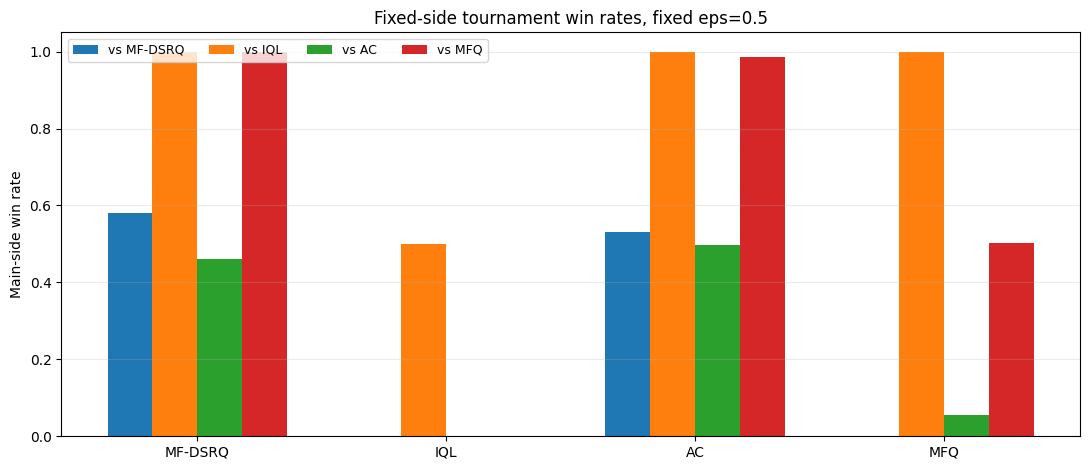

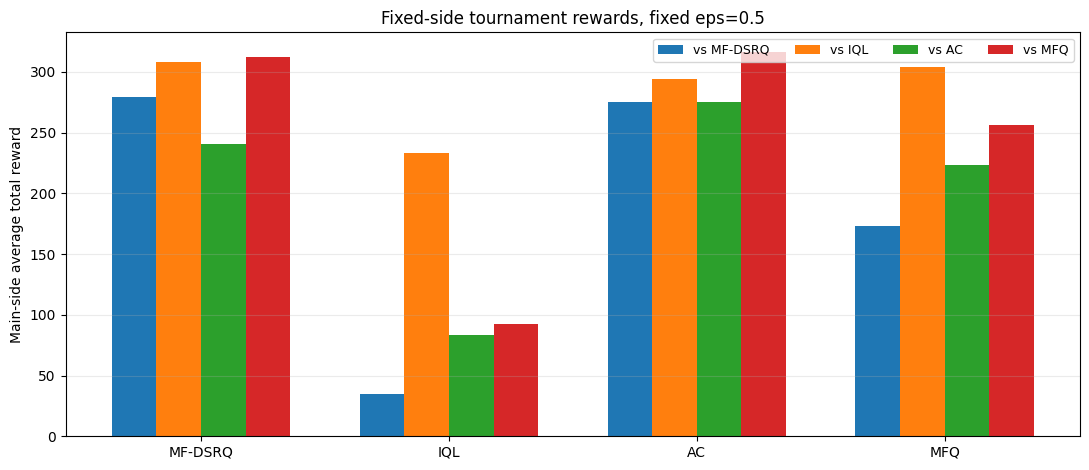

In [8]:
tournament_fixed_0_5 = evaluate_and_plot_model("fixed_0_5")
TOURNAMENTS["fixed_0_5"] = tournament_fixed_0_5
fixed_side_tournament_table(tournament_fixed_0_5)


## Fixed Robust Epsilon 0.5 Training History


Saved training history plot to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/fixed_0_5_training_history.png


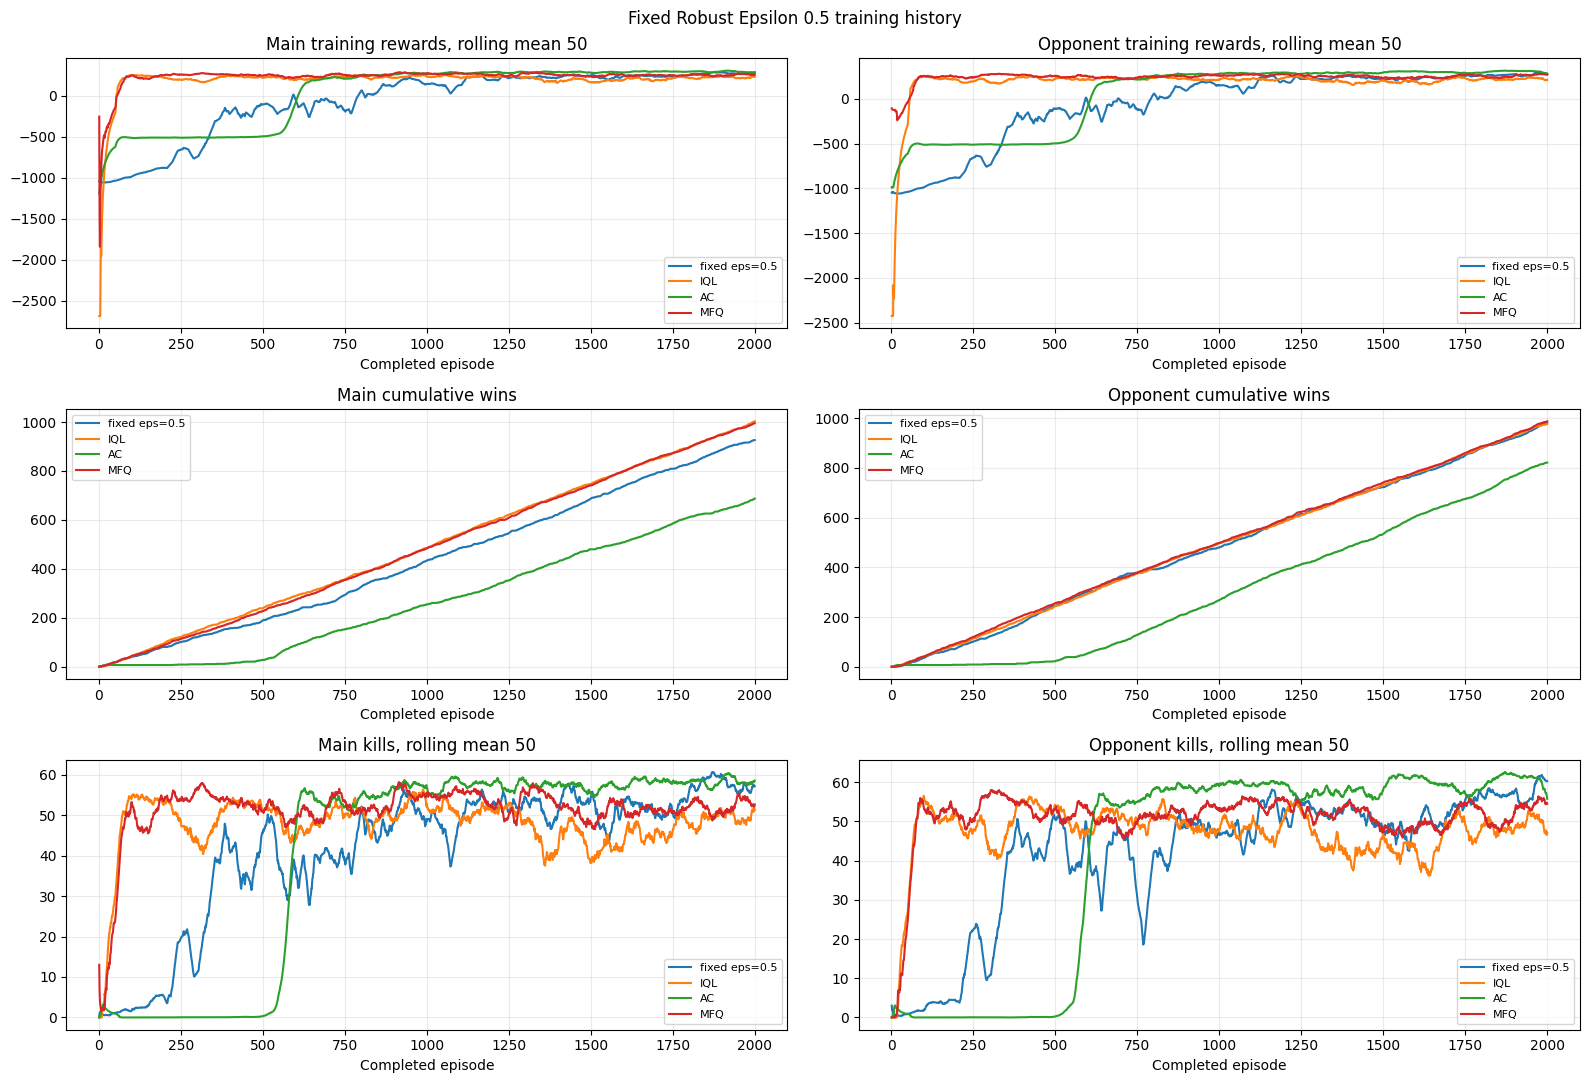

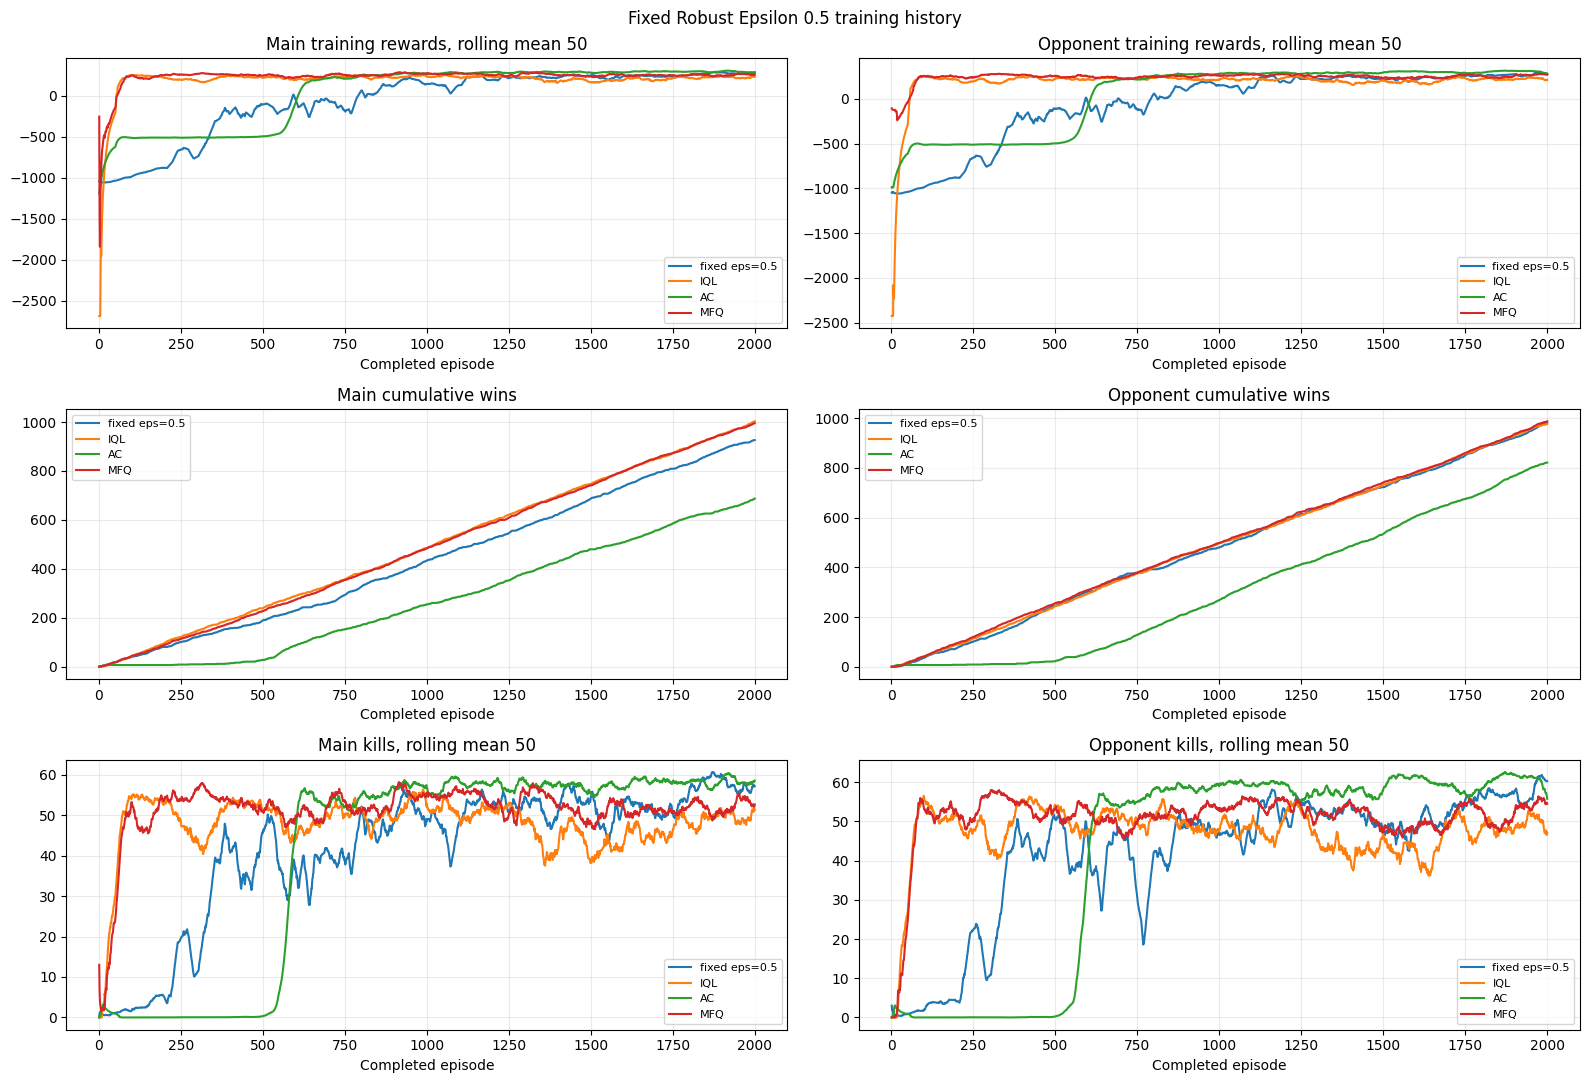

In [9]:
plot_training_history_group(
    ("fixed_0_5",),
    "Fixed Robust Epsilon 0.5 training history",
    "fixed_0_5_training_history",
)


## Fixed Robust Epsilon 1.0

In [10]:
# tournament_fixed_1_0 = evaluate_and_plot_model("fixed_1_0")
# TOURNAMENTS["fixed_1_0"] = tournament_fixed_1_0
# fixed_side_tournament_table(tournament_fixed_1_0)


## Fixed Robust Epsilon 1.0 Training History

In [11]:
# plot_training_history_group(
#     ("fixed_1_0",),
#     "Fixed Robust Epsilon 1.0 training history",
#     "fixed_1_0_training_history",
# )

## Decay-to-Zero Robust Epsilon Tournaments


## Decay Robust Epsilon 0.5 -> 0


MF-DSRQ eps=0 eval episodes:   0%|                                                             | 0/3500 [00:00…

Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_0_5_to_0/battle_v4/seed42/ckpt_opponent_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_0_5_to_0/battle_v4/seed42/ckpt_main_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_0_5_to_0/battle_v4/seed42/ckpt_opponent_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_0_5_to_0/battle_v4/seed42/ckpt_main_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_0_5_to_0/battle_v4/seed42/ckpt_main_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_0_5_to_0/battle_v4/seed42/ck

,main algo name,opponent algo name,main win rate,opponent win rate,avg main kills,avg opponent kills,avg main rewards,avg opponent rewards
0,mfdsrq,mfdsrq,0.488,0.512,54.388,54.120,255.359406,254.270075
1,mfdsrq,iql,1.000,0.000,63.700,6.320,-1.077485,-18.163703
2,mfdsrq,ac,0.502,0.486,58.230,53.964,279.237235,253.910348
3,mfdsrq,mfq,0.984,0.008,57.816,45.028,257.659350,198.705807
4,iql,mfdsrq,0.000,1.000,9.650,63.848,7.904327,74.298434
5,iql,iql,0.500,0.500,50.270,47.804,233.453977,217.030379
6,iql,ac,0.000,1.000,23.828,63.928,83.704734,289.629540
7,iql,mfq,0.000,1.000,25.798,64.000,92.361025,315.205226
8,ac,mfdsrq,0.444,0.544,52.822,59.204,250.336819,284.538526
9,ac,iql,1.000,0.000,63.914,22.738,293.901538,78.437894


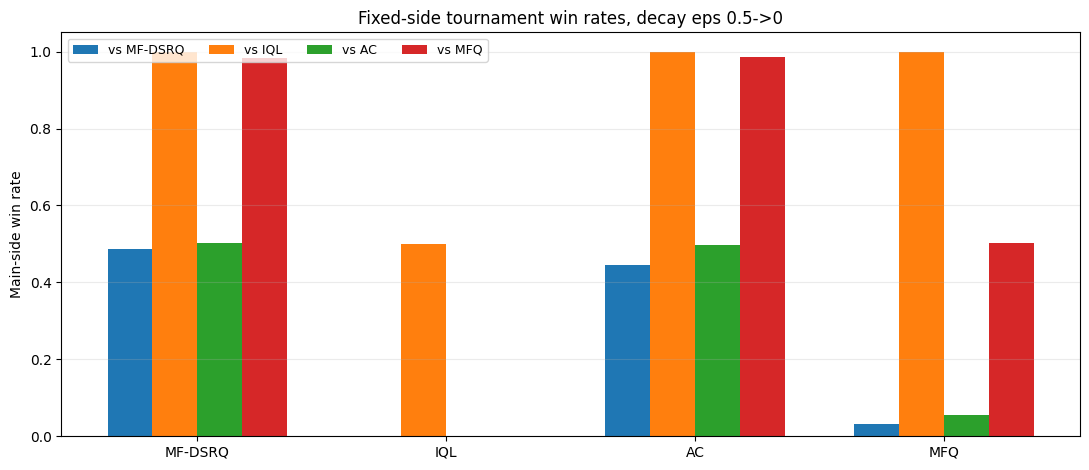

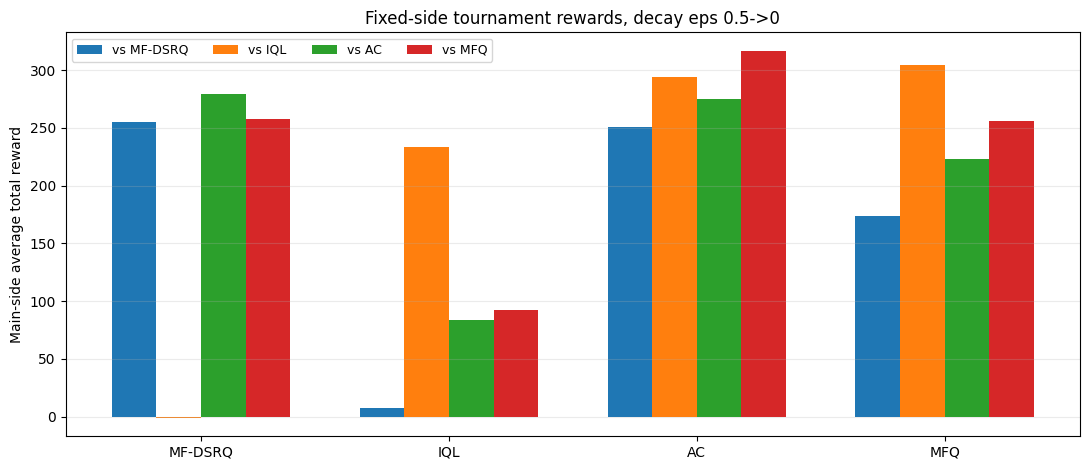

In [12]:
tournament_decay_0_5_to_0 = evaluate_and_plot_model("decay_0_5_to_0")
TOURNAMENTS["decay_0_5_to_0"] = tournament_decay_0_5_to_0
fixed_side_tournament_table(tournament_decay_0_5_to_0)


## Decay Robust Epsilon 0.5 -> 0 Training History


Saved training history plot to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/decay_0_5_to_0_training_history.png


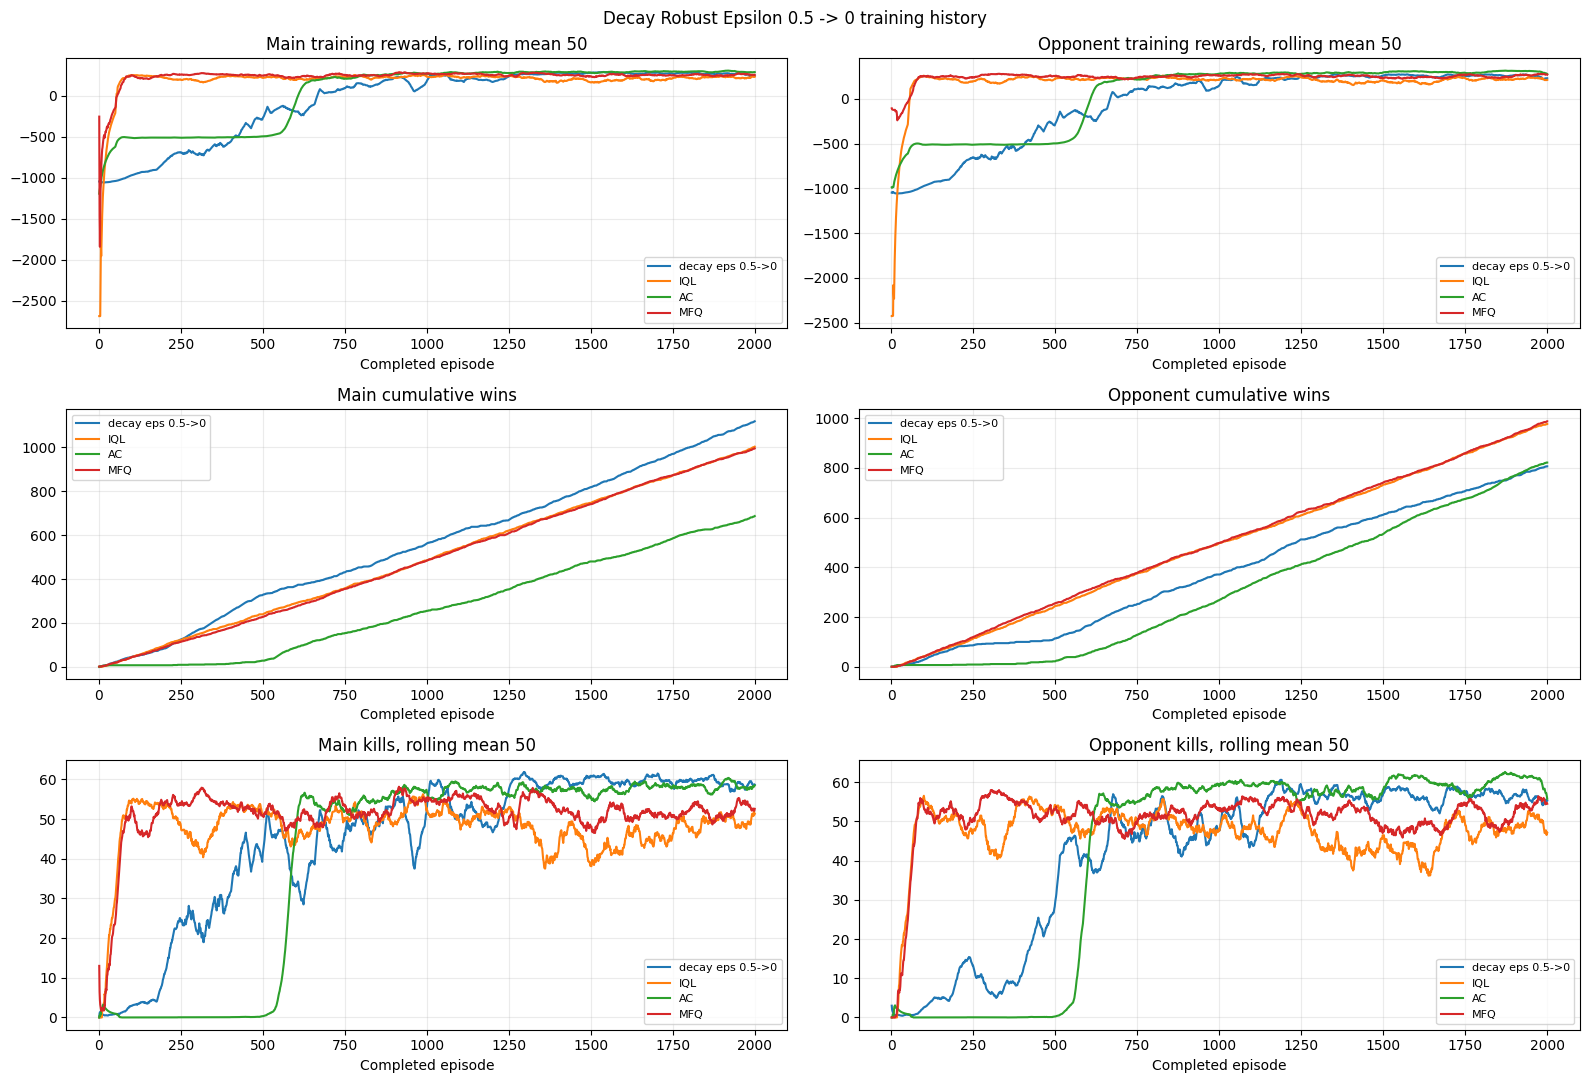

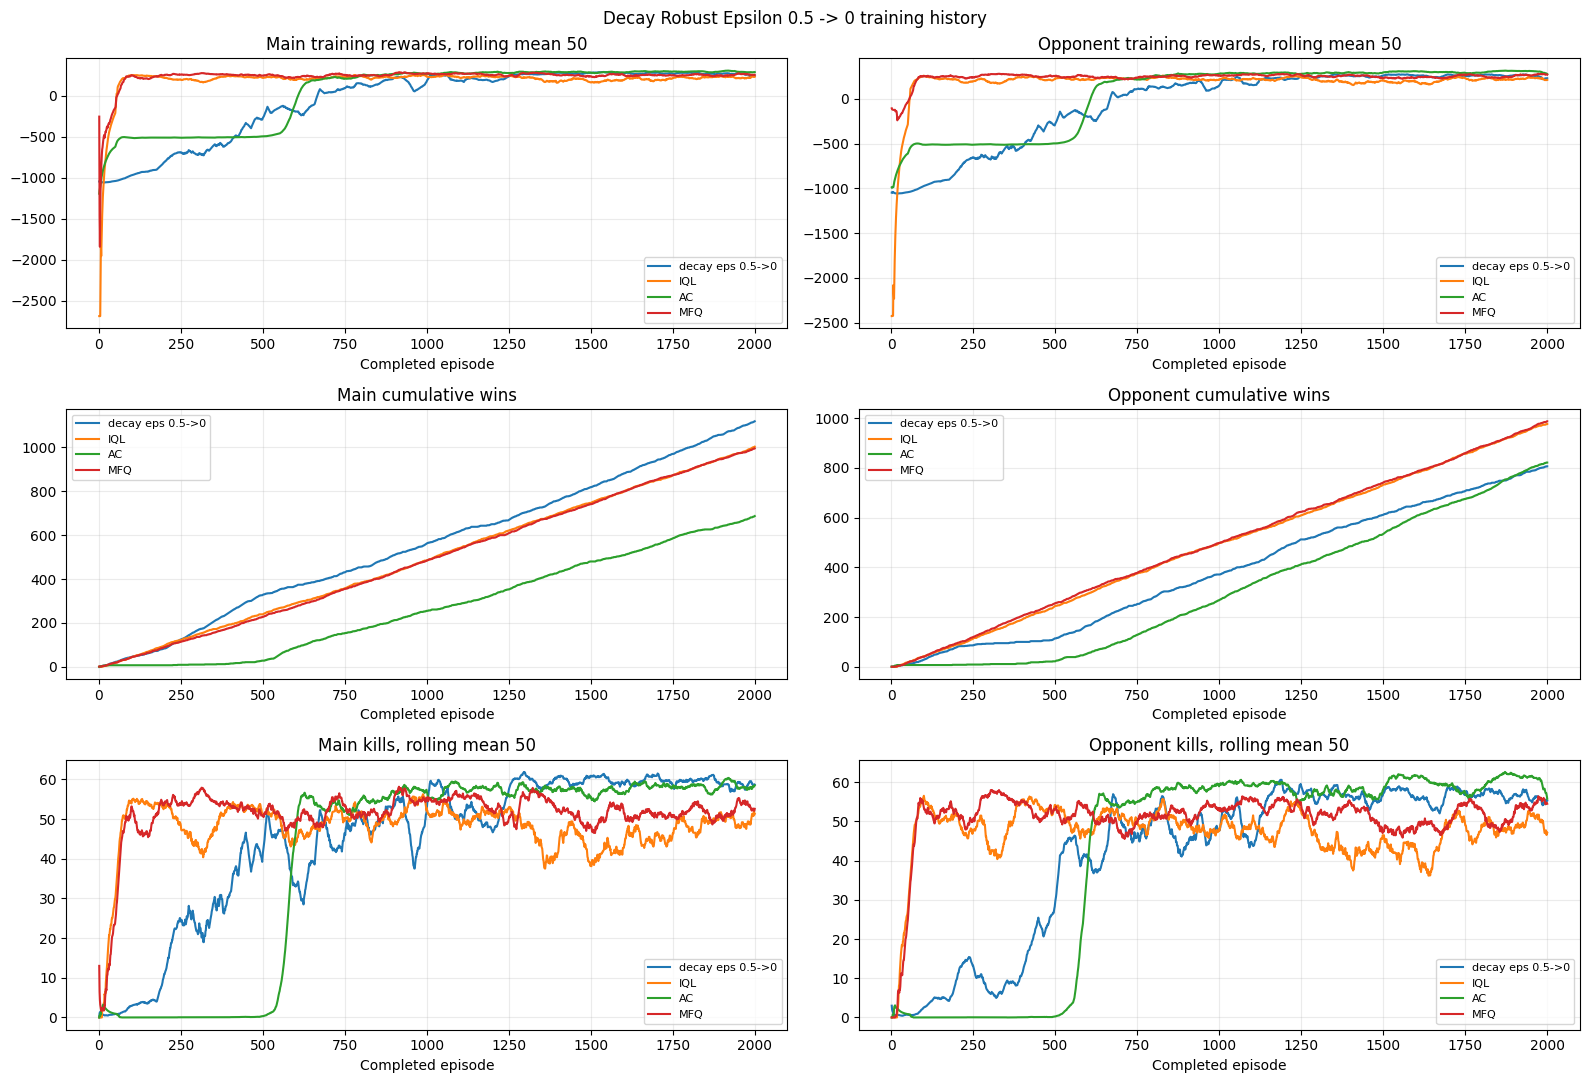

In [13]:
plot_training_history_group(
    ("decay_0_5_to_0",),
    "Decay Robust Epsilon 0.5 -> 0 training history",
    "decay_0_5_to_0_training_history",
)


## Decay Robust Epsilon 0.75 -> 0


MF-DSRQ eps=0 eval episodes:   0%|                                                             | 0/3500 [00:00…

Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_0_75_to_0/battle_v4/seed42/ckpt_opponent_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_0_75_to_0/battle_v4/seed42/ckpt_main_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_0_75_to_0/battle_v4/seed42/ckpt_opponent_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_0_75_to_0/battle_v4/seed42/ckpt_main_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_0_75_to_0/battle_v4/seed42/ckpt_opponent_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_0_75_to_0/battle_v4

,main algo name,opponent algo name,main win rate,opponent win rate,avg main kills,avg opponent kills,avg main rewards,avg opponent rewards
0,mfdsrq,mfdsrq,0.672,0.308,60.566,57.412,265.829100,262.040733
1,mfdsrq,iql,1.000,0.000,56.676,15.372,185.765178,29.458164
2,mfdsrq,ac,0.006,0.990,51.092,62.234,237.644047,270.937266
3,mfdsrq,mfq,0.692,0.232,54.872,46.254,237.874994,206.549045
4,iql,mfdsrq,0.000,1.000,14.962,60.442,30.279295,226.207532
5,iql,iql,0.500,0.500,50.270,47.804,233.453977,217.030379
6,iql,ac,0.000,1.000,23.828,63.928,83.704734,289.629540
7,iql,mfq,0.000,1.000,25.798,64.000,92.361025,315.205226
8,ac,mfdsrq,0.982,0.016,62.248,51.804,275.628585,241.138486
9,ac,iql,1.000,0.000,63.914,22.738,293.901538,78.437894


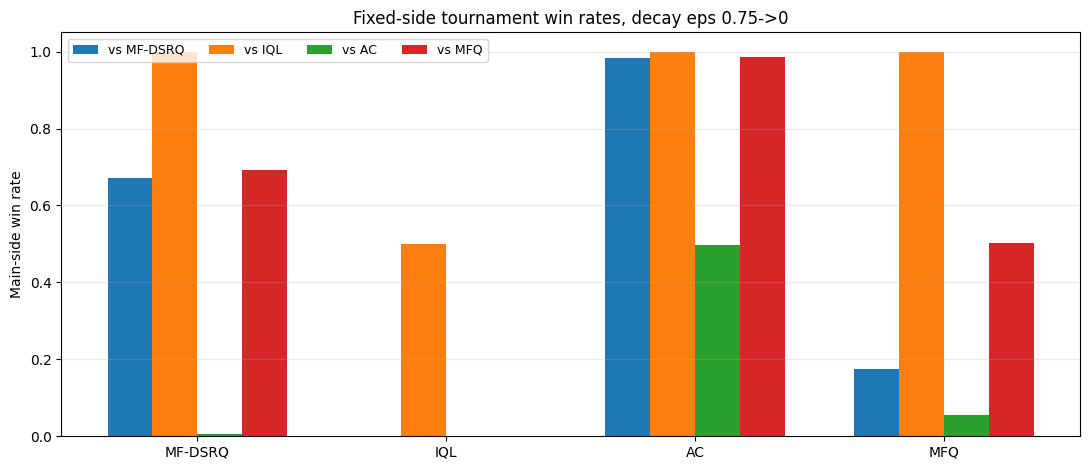

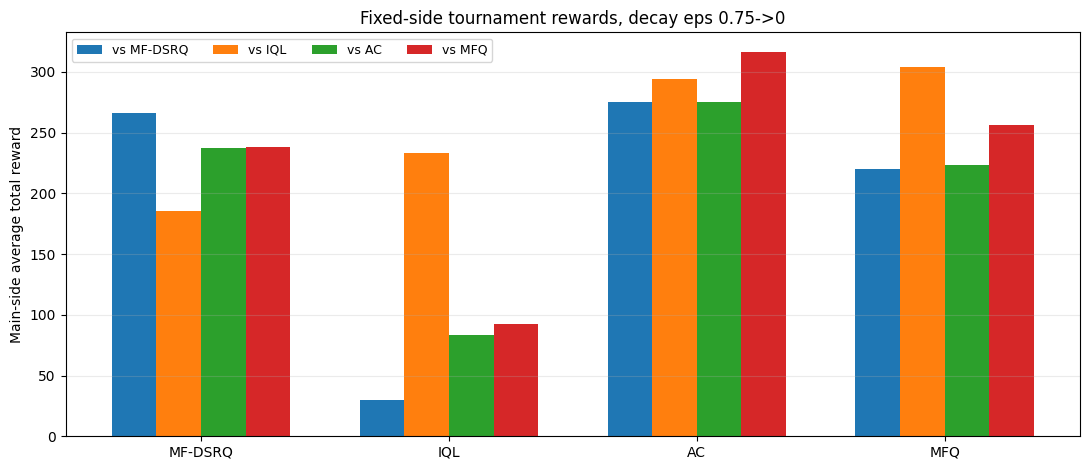

In [14]:
tournament_decay_0_75_to_0 = evaluate_and_plot_model("decay_0_75_to_0")
TOURNAMENTS["decay_0_75_to_0"] = tournament_decay_0_75_to_0
fixed_side_tournament_table(tournament_decay_0_75_to_0)


## Decay Robust Epsilon 0.75 -> 0 Training History


Saved training history plot to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/decay_0_75_to_0_training_history.png


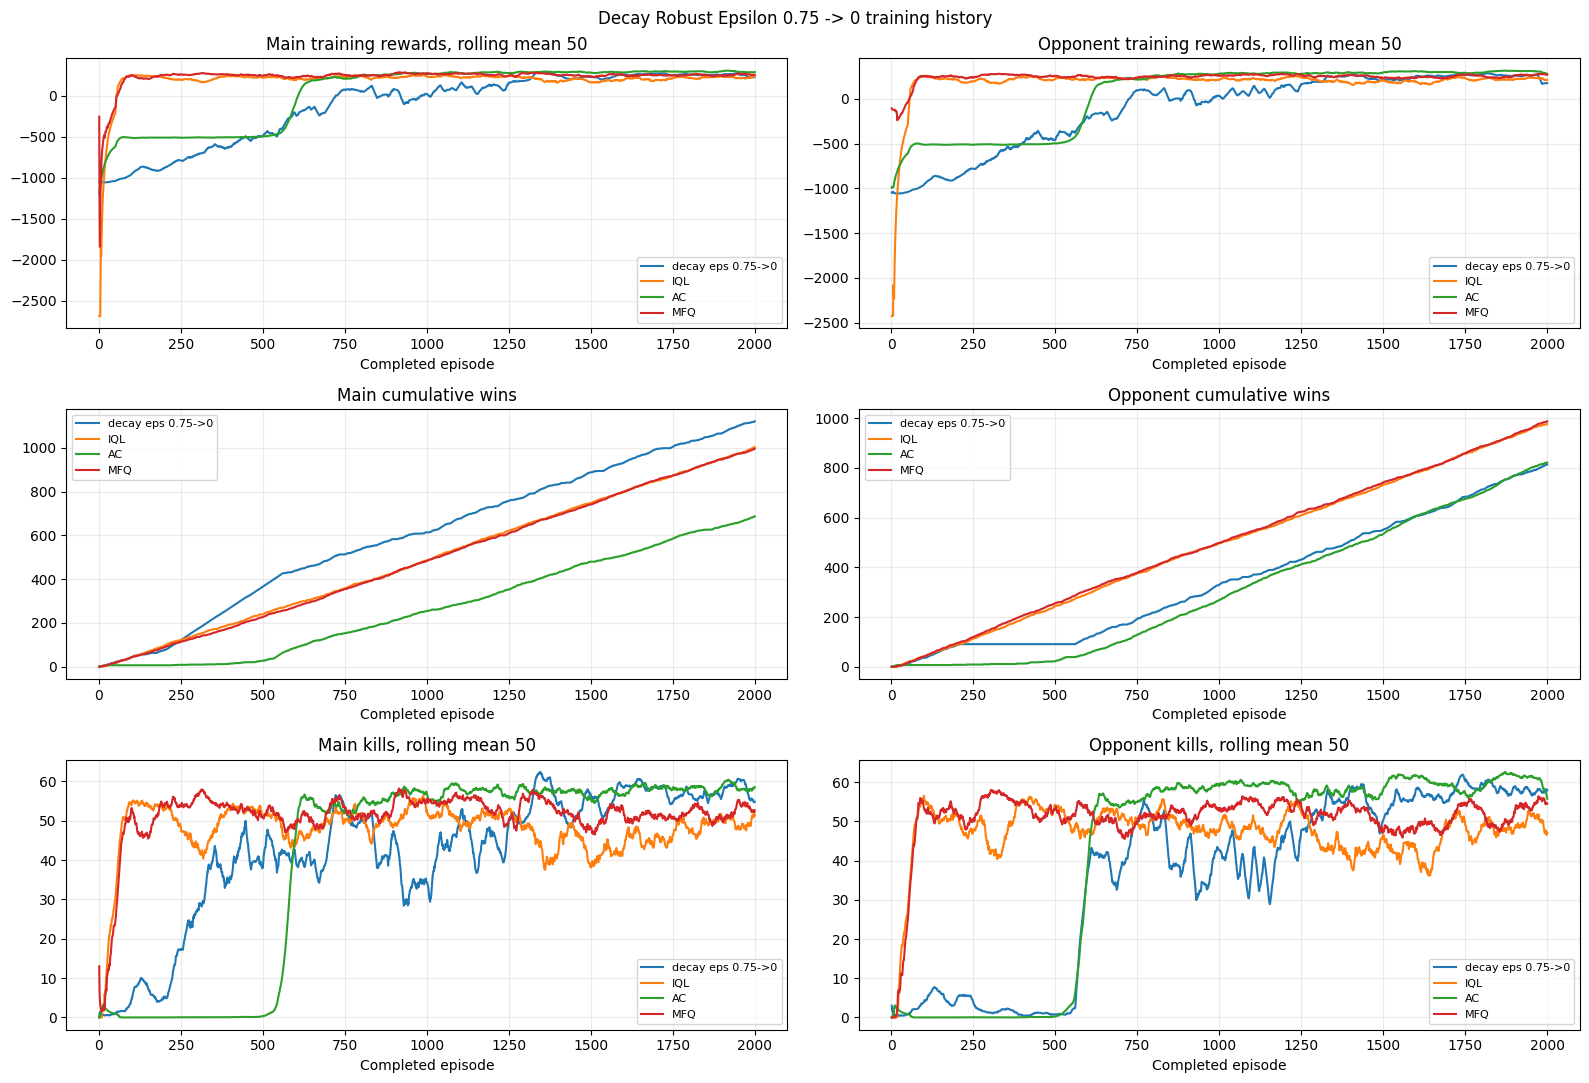

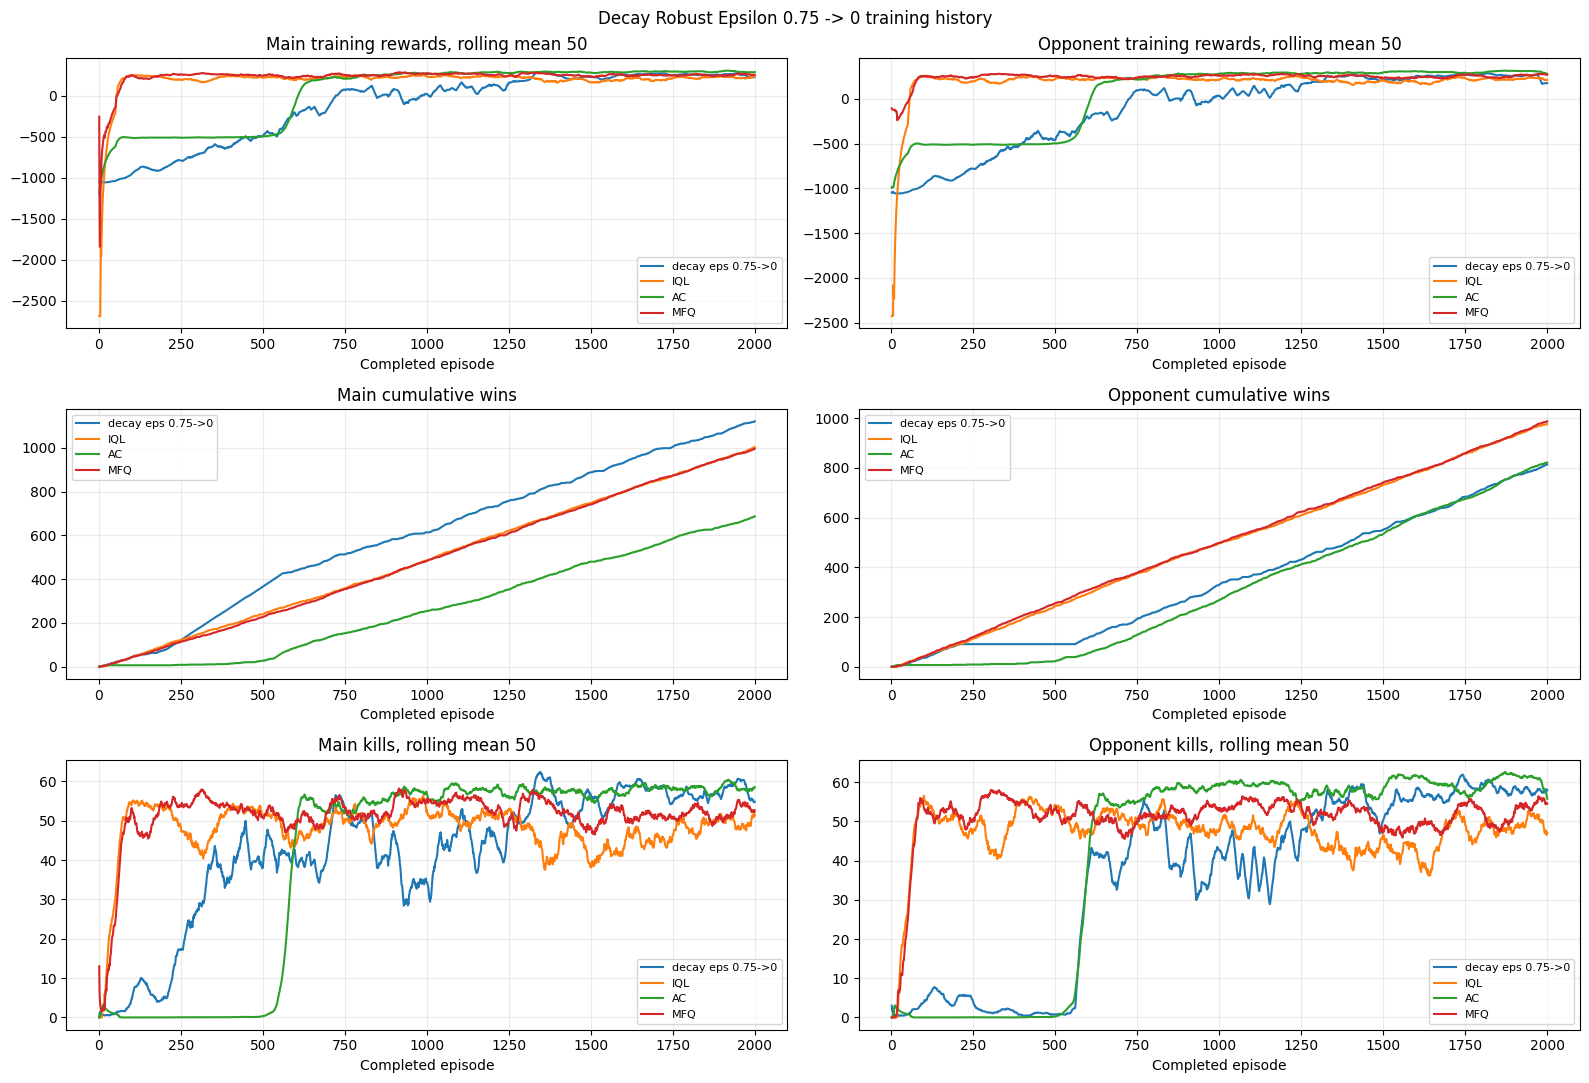

In [15]:
plot_training_history_group(
    ("decay_0_75_to_0",),
    "Decay Robust Epsilon 0.75 -> 0 training history",
    "decay_0_75_to_0_training_history",
)


## Decay Robust Epsilon 1.0 -> 0


MF-DSRQ eps=0 eval episodes:   0%|                                                             | 0/3500 [00:00…

Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_1_to_0/battle_v4/seed42/ckpt_opponent_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_1_to_0/battle_v4/seed42/ckpt_opponent_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_1_to_0/battle_v4/seed42/ckpt_main_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_1_to_0/battle_v4/seed42/ckpt_opponent_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_1_to_0/battle_v4/seed42/ckpt_main_best.pt
Loaded /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero_v4_opp/start_1_to_0/battle_v4/seed42/ckpt_main_

,main algo name,opponent algo name,main win rate,opponent win rate,avg main kills,avg opponent kills,avg main rewards,avg opponent rewards
0,mfdsrq,mfdsrq,0.802,0.194,63.010,57.270,295.065375,265.199500
1,mfdsrq,iql,1.000,0.000,64.000,10.412,290.027908,15.223916
2,mfdsrq,ac,0.218,0.776,48.356,62.054,224.602138,307.707706
3,mfdsrq,mfq,0.808,0.152,62.802,57.886,286.772296,282.137927
4,iql,mfdsrq,0.000,1.000,9.574,64.000,14.764997,289.855480
5,iql,iql,0.500,0.500,50.270,47.804,233.453977,217.030379
6,iql,ac,0.000,1.000,23.828,63.928,83.704734,289.629540
7,iql,mfq,0.000,1.000,25.798,64.000,92.361025,315.205226
8,ac,mfdsrq,0.636,0.362,60.612,50.410,301.019637,234.759868
9,ac,iql,1.000,0.000,63.914,22.738,293.901538,78.437894


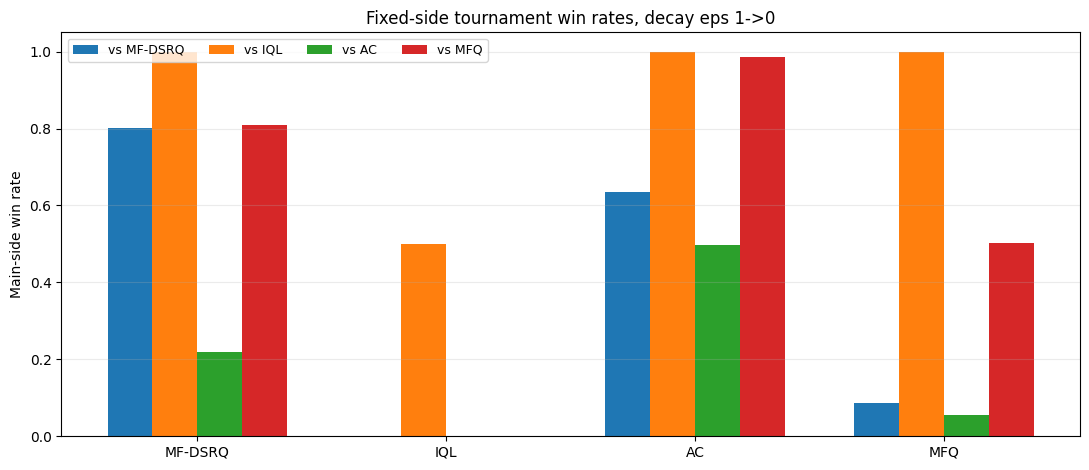

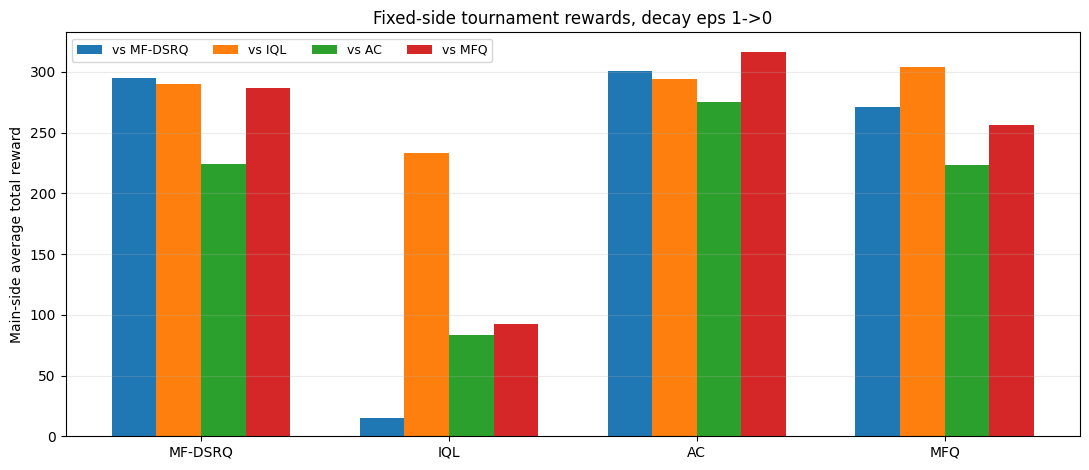

In [16]:
tournament_decay_1_0_to_0 = evaluate_and_plot_model("decay_1_0_to_0")
TOURNAMENTS["decay_1_0_to_0"] = tournament_decay_1_0_to_0
fixed_side_tournament_table(tournament_decay_1_0_to_0)


## Decay Robust Epsilon 1.0 -> 0 Training History


Saved training history plot to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training_v4_opp/decay_1_0_to_0_training_history.png


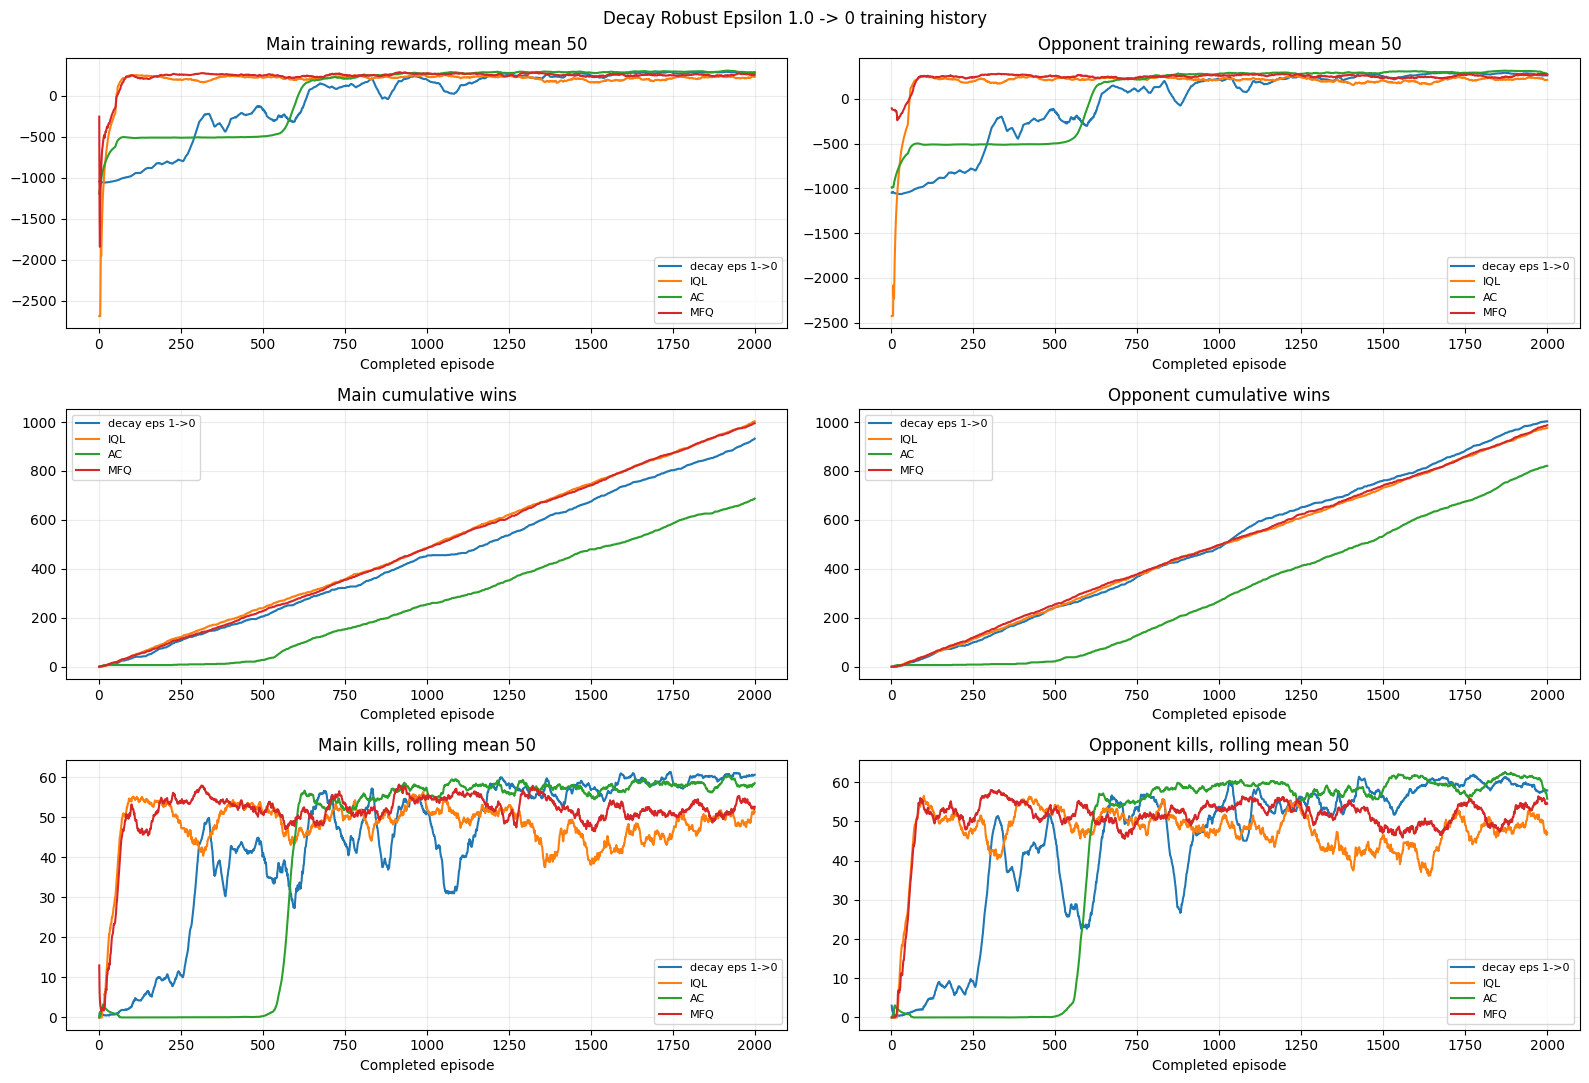

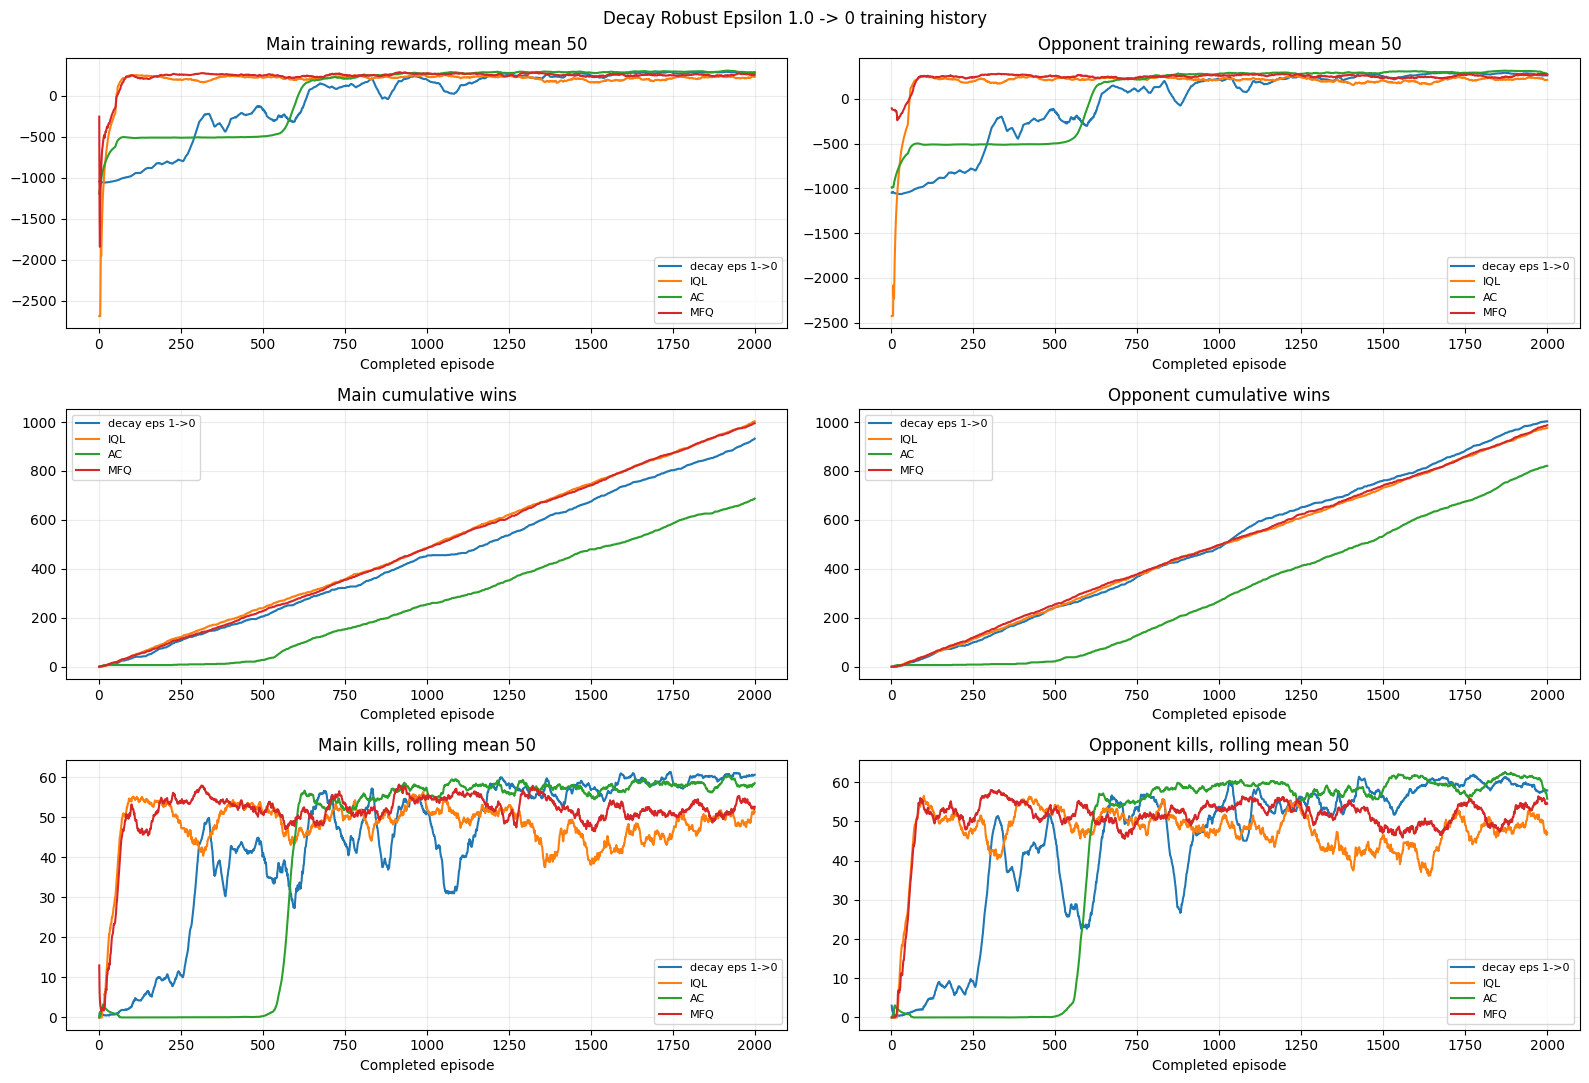

In [17]:
plot_training_history_group(
    ("decay_1_0_to_0",),
    "Decay Robust Epsilon 1.0 -> 0 training history",
    "decay_1_0_to_0_training_history",
)


## Ramp-Up Robust Epsilon Tournaments


## Ramp Robust Epsilon 0.01 -> 0.5


In [18]:
# tournament_ramp_0_01_to_0_5 = evaluate_and_plot_model("ramp_0_01_to_0_5")
# TOURNAMENTS["ramp_0_01_to_0_5"] = tournament_ramp_0_01_to_0_5
# fixed_side_tournament_table(tournament_ramp_0_01_to_0_5)


## Ramp Robust Epsilon 0.01 -> 0.5 Training History


In [19]:
# plot_training_history_group(
#     ("ramp_0_01_to_0_5",),
#     "Ramp Robust Epsilon 0.01 -> 0.5 training history",
#     "ramp_0_01_to_0_5_training_history",
# )


## Ramp Robust Epsilon 0.01 -> 1.0


In [20]:
# tournament_ramp_0_01_to_1_0 = evaluate_and_plot_model("ramp_0_01_to_1_0")
# TOURNAMENTS["ramp_0_01_to_1_0"] = tournament_ramp_0_01_to_1_0
# fixed_side_tournament_table(tournament_ramp_0_01_to_1_0)


## Ramp Robust Epsilon 0.01 -> 1.0 Training History


In [21]:
# plot_training_history_group(
#     ("ramp_0_01_to_1_0",),
#     "Ramp Robust Epsilon 0.01 -> 1.0 training history",
#     "ramp_0_01_to_1_0_training_history",
# )


## Ramp Robust Epsilon 0.1 -> 0.5


In [22]:
# tournament_ramp_0_1_to_0_5 = evaluate_and_plot_model("ramp_0_1_to_0_5")
# TOURNAMENTS["ramp_0_1_to_0_5"] = tournament_ramp_0_1_to_0_5
# fixed_side_tournament_table(tournament_ramp_0_1_to_0_5)


## Ramp Robust Epsilon 0.1 -> 0.5 Training History


In [23]:
# plot_training_history_group(
#     ("ramp_0_1_to_0_5",),
#     "Ramp Robust Epsilon 0.1 -> 0.5 training history",
#     "ramp_0_1_to_0_5_training_history",
# )


## Ramp Robust Epsilon 0.1 -> 1.0


In [24]:
# tournament_ramp_0_1_to_1_0 = evaluate_and_plot_model("ramp_0_1_to_1_0")
# TOURNAMENTS["ramp_0_1_to_1_0"] = tournament_ramp_0_1_to_1_0
# fixed_side_tournament_table(tournament_ramp_0_1_to_1_0)


## Ramp Robust Epsilon 0.1 -> 1.0 Training History


In [25]:
# plot_training_history_group(
#     ("ramp_0_1_to_1_0",),
#     "Ramp Robust Epsilon 0.1 -> 1.0 training history",
#     "ramp_0_1_to_1_0_training_history",
# )


## Aggregate Table


In [26]:
all_rows = []
for model_key, tournament in TOURNAMENTS.items():
    for row in tournament["rows"]:
        all_rows.append({
            "model_key": model_key,
            "model_label": MFDSRQ_MODEL_SPECS[model_key]["label"],
            **row,
        })
pd.DataFrame(all_rows)


,model_key,model_label,main_algorithm,opponent_algorithm,main_win_rate,opponent_win_rate,tie_rate,mean_main_kills,mean_opponent_kills,mean_main_reward,mean_opponent_reward,episodes
0,fixed_0_01,fixed eps=0.01,mfdsrq,mfdsrq,0.586,0.408,0.006,60.502,53.700,255.674067,228.079328,500
1,fixed_0_01,fixed eps=0.01,mfdsrq,iql,1.000,0.000,0.000,63.446,23.530,-166.238673,47.087670,500
2,fixed_0_01,fixed eps=0.01,mfdsrq,ac,0.524,0.430,0.046,61.330,59.272,263.805946,286.974934,500
3,fixed_0_01,fixed eps=0.01,mfdsrq,mfq,1.000,0.000,0.000,64.000,37.164,308.664816,173.329590,500
4,fixed_0_01,fixed eps=0.01,iql,mfdsrq,0.000,1.000,0.000,21.662,63.048,35.281842,-339.775298,500
...,...,...,...,...,...,...,...,...,...,...,...,...
91,decay_1_0_to_0,decay eps 1->0,ac,mfq,0.986,0.012,0.002,63.916,43.302,316.766617,203.523710,500
92,decay_1_0_to_0,decay eps 1->0,mfq,mfdsrq,0.086,0.874,0.040,56.430,62.794,271.484388,284.214058,500
93,decay_1_0_to_0,decay eps 1->0,mfq,iql,1.000,0.000,0.000,63.934,29.844,304.106907,108.670302,500
94,decay_1_0_to_0,decay eps 1->0,mfq,ac,0.056,0.944,0.000,47.510,63.558,222.979880,313.478098,500
